# Session 1 — Introduction to Text Analytics & Text Classification

<div style='background:linear-gradient(135deg,#1a237e,#283593);color:#fff;padding:20px 24px;border-radius:8px;margin:8px 0'>
<h3 style='margin:0 0 8px'>PES University · NLP Course</h3>
<p style='margin:0;opacity:.85'>A self-contained teaching notebook · Works in Colab and local Jupyter</p>
</div>

---
## 0. Environment Setup

**Colab one-liner** (paste in a new cell if you prefer):
```
!pip install nltk spacy gensim scikit-learn textblob pyspellchecker==0.7.2 emoji wordcloud seaborn pdfminer.six beautifulsoup4 requests
!python -m spacy download en_core_web_sm
```

In [ ]:
import sys, subprocess

PACKAGES = [
    'numpy>=1.24','pandas>=2.0','matplotlib>=3.7','seaborn>=0.13',
    'nltk>=3.8','spacy>=3.7','gensim>=4.3','scikit-learn>=1.3',
    'textblob>=0.18','pyspellchecker==0.7.2','emoji>=2.8',
    'wordcloud>=1.9','requests>=2.31','beautifulsoup4>=4.12',
    'pdfminer.six>=20221105',
]

def _install(pkg):
    try:
        subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'],
                              stderr=subprocess.DEVNULL)
        print(f'  ✓ {pkg}')
    except Exception as e:
        print(f'  ✗ {pkg}: {e}')

print('Installing packages...')
for p in PACKAGES:
    _install(p)
print('Done.')

Installing packages...
  ✓ numpy>=1.24
  ✓ pandas>=2.0
  ✓ matplotlib>=3.7
  ✓ seaborn>=0.13
  ✓ nltk>=3.8
  ✓ spacy>=3.7
  ✓ gensim>=4.3
  ✓ scikit-learn>=1.3
  ✓ textblob>=0.18
  ✓ pyspellchecker==0.7.2
  ✓ emoji>=2.8
  ✓ wordcloud>=1.9
  ✓ requests>=2.31
  ✓ beautifulsoup4>=4.12
  ✓ pdfminer.six>=20221105
Done.


Imports core libraries (NumPy, pandas, Matplotlib, seaborn, logging) and detects
the runtime environment. `IN_COLAB` is `True` on Google Colab and `False` on local
Jupyter. `DATA_DIR` resolves to the correct data path for each environment.

In [ ]:
import os, sys, pathlib, re, string, unicodedata, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
%matplotlib inline

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
log = logging.getLogger('nlp_session1')

IN_COLAB = 'google.colab' in sys.modules
DATA_DIR  = pathlib.Path('/content') if IN_COLAB else pathlib.Path('../../data')
log.info('Running in %s | DATA_DIR = %s', 'Colab' if IN_COLAB else 'local Jupyter', DATA_DIR)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi':110,'figure.facecolor':'white'})
print('Core imports OK')

INFO: Running in local Jupyter | DATA_DIR = ..\..\data


Core imports OK


Downloads all NLTK data packages needed for this session — tokenizers, POS taggers,
named entity recogniser, WordNet, sentiment lexicon — silently handling both NLTK 3.8
and 3.9+ package name changes. Also loads the spaCy English model.

In [ ]:
import nltk, warnings
warnings.filterwarnings('ignore')

NLTK_PKGS = [
    'punkt','punkt_tab','stopwords','averaged_perceptron_tagger',
    'averaged_perceptron_tagger_eng','tagsets','tagsets_json',
    'maxent_ne_chunker','maxent_ne_chunker_tab','words',
    'reuters','wordnet','vader_lexicon','omw-1.4',
]
for pkg in NLTK_PKGS:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

try:
    import spacy
    nlp = spacy.load('en_core_web_sm')
    print('spaCy en_core_web_sm loaded')
except OSError:
    log.warning('spaCy model missing – run: python -m spacy download en_core_web_sm')
    nlp = None

print('NLTK packages downloaded')

NLTK packages downloaded


Defines `show_mermaid()`, a helper that renders Mermaid flowchart diagrams inline in
the notebook. It injects the Mermaid.js library from CDN and uses `mermaid.run()` on
a unique div ID, making it compatible with both Colab and local Jupyter.

In [ ]:
from IPython.display import display, HTML
import uuid as _uuid

def show_mermaid(diagram, height=None):
    """Render a Mermaid diagram inline (requires internet)."""
    did = 'mm-' + _uuid.uuid4().hex[:8]
    h_style = f'min-height:{height}px;' if height else ''
    display(HTML(f'''
    <div id="{did}" class="mermaid" style="{h_style}padding:8px;">{diagram}</div>
    <script>
    (function(){{
        function render(){{
            mermaid.initialize({{startOnLoad:false,theme:'default',
                flowchart:{{htmlLabels:true,curve:'basis'}}}});
            mermaid.run({{nodes:[document.getElementById("{did}")]}});
        }}
        if(typeof mermaid!=='undefined'){{ render(); }}
        else{{
            var s=document.createElement('script');
            s.src='https://cdn.jsdelivr.net/npm/mermaid@10/dist/mermaid.min.js';
            s.onload=render;
            document.head.appendChild(s);
        }}
    }})();
    </script>'''))

print('show_mermaid helper ready')

show_mermaid helper ready


---
<a id='s1'></a>
## 1. What is Natural Language Processing?

**Natural Language Processing (NLP)** is a branch of Artificial Intelligence concerned with enabling computers to **understand, interpret, and generate** human language.

> *"Language is the most massive and inclusive art we know, a mountainous and anonymous work of unconscious generations."* — Edward Sapir

### Why is it hard?
- **Ambiguity**: "I saw the man with the telescope" (who has the telescope?)
- **Context dependence**: "It" can refer to many things
- **World knowledge**: "The trophy didn't fit in the suitcase because it was too big"
- **Idioms**: "It's raining cats and dogs"
- **Sarcasm / irony**: "Oh great, another Monday"

<div style="background:#fce4ec;border-left:5px solid #E91E63;padding:12px 16px;border-radius:4px;margin:8px 0"><b>🎯 Learning Objectives</b><br/>
After this section you will be able to:<br/>
• Define NLP and explain why it is difficult<br/>
• List major NLP application domains<br/>
• Describe the standard NLP processing pipeline
</div>

Groups 14 NLP tasks by problem type (Text Processing through LLM/Advanced) and arranges them left-to-right by course complexity. The coloured bars tell students what topic they are learning and the annotation shows which session it is covered in.

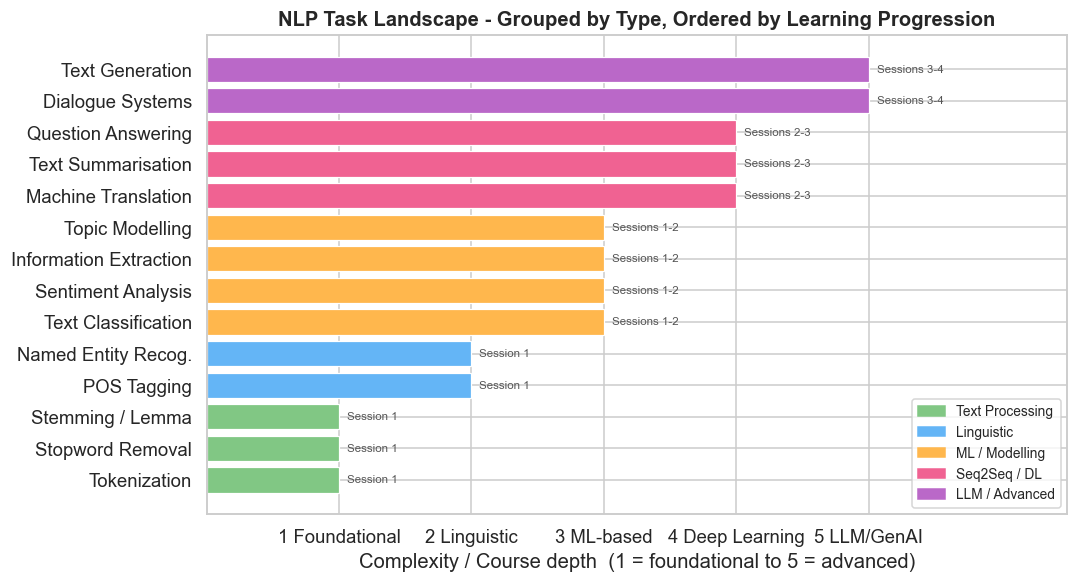

In [ ]:
# NLP tasks grouped by problem type, ordered by learning progression
import matplotlib.pyplot as plt, matplotlib.patches as mpatches, numpy as np

tasks = [
    ('Tokenization',          'Text Processing', 1),
    ('Stopword Removal',      'Text Processing', 1),
    ('Stemming / Lemma',      'Text Processing', 1),
    ('POS Tagging',           'Linguistic',      2),
    ('Named Entity Recog.',   'Linguistic',      2),
    ('Text Classification',   'ML / Modelling',  3),
    ('Sentiment Analysis',    'ML / Modelling',  3),
    ('Information Extraction','ML / Modelling',  3),
    ('Topic Modelling',       'ML / Modelling',  3),
    ('Machine Translation',   'Seq2Seq / DL',    4),
    ('Text Summarisation',    'Seq2Seq / DL',    4),
    ('Question Answering',    'Seq2Seq / DL',    4),
    ('Dialogue Systems',      'LLM / Advanced',  5),
    ('Text Generation',       'LLM / Advanced',  5),
]
group_colors = {
    'Text Processing': '#81c784',
    'Linguistic':      '#64b5f6',
    'ML / Modelling':  '#ffb74d',
    'Seq2Seq / DL':    '#f06292',
    'LLM / Advanced':  '#ba68c8',
}
session_label = ['','Session 1','Session 1','Sessions 1-2','Sessions 2-3','Sessions 3-4']

labels  = [t[0] for t in tasks]
colors  = [group_colors[t[1]] for t in tasks]
levels  = [t[2] for t in tasks]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(labels, levels, color=colors, edgecolor='white', linewidth=0.8)
ax.set_xlabel('Complexity / Course depth  (1 = foundational to 5 = advanced)')
ax.set_title('NLP Task Landscape - Grouped by Type, Ordered by Learning Progression',
             fontweight='bold')
ax.set_xlim(0, 6.5)
ax.set_xticks([1,2,3,4,5])
ax.set_xticklabels(['1 Foundational','2 Linguistic','3 ML-based','4 Deep Learning','5 LLM/GenAI'])
legend_handles = [mpatches.Patch(color=c, label=g) for g, c in group_colors.items()]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)
for bar, t in zip(bars, tasks):
    ax.text(bar.get_width()+0.06, bar.get_y()+bar.get_height()/2,
            session_label[t[2]], va='center', fontsize=7.5, color='#555')
plt.tight_layout(); plt.show()


### 1.1 NLP Challenges — Difficulty by Category

Scores eight NLP tasks on a 1–10 difficulty scale for both rule-based and deep-learning approaches and renders a grouped bar chart. Tasks on the left (tokenisation, POS tagging) are easy with rules; tasks on the right (reasoning, translation) require neural models.

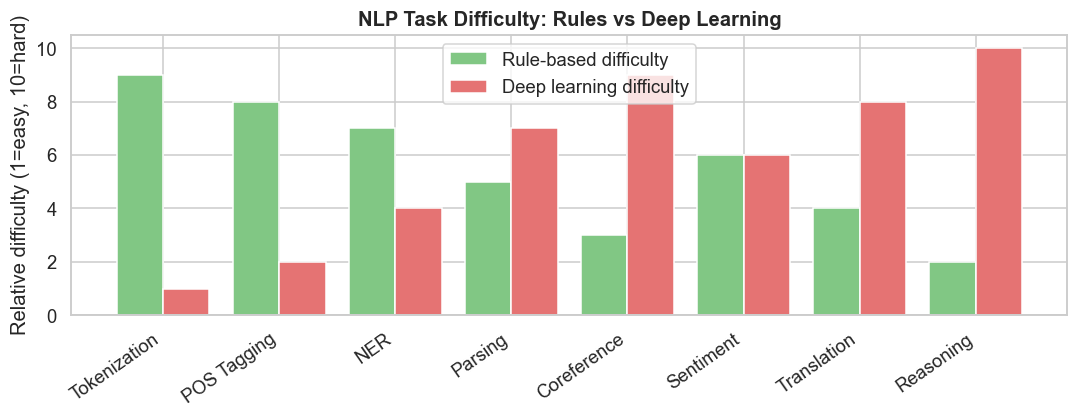

In [ ]:
categories = ['Tokenization','POS Tagging','NER','Parsing','Coreference','Sentiment','Translation','Reasoning']
easy_score  = [9, 8, 7, 5, 3, 6, 4, 2]
hard_score  = [1, 2, 4, 7, 9, 6, 8, 10]

x = np.arange(len(categories))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x-0.2, easy_score, 0.4, label='Rule-based difficulty', color='#81c784')
ax.bar(x+0.2, hard_score, 0.4, label='Deep learning difficulty', color='#e57373')
ax.set_xticks(x); ax.set_xticklabels(categories, rotation=35, ha='right')
ax.set_ylabel('Relative difficulty (1=easy, 10=hard)')
ax.set_title('NLP Task Difficulty: Rules vs Deep Learning', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

### 1.2 The NLP Processing Pipeline

Renders the standard NLP processing pipeline as a left-to-right flowchart: Raw Text → Tokenization → Normalization → Noise Removal → Feature Extraction → Modelling → Application. Each arrow represents a transformation stage.

In [ ]:
show_mermaid('''
flowchart LR
    A([Raw Text]) --> B[Tokenization]
    B --> C[Normalization]
    C --> D[Noise Removal]
    D --> E[Feature Extraction]
    E --> F[Modelling]
    F --> G([Application])
    style A fill:#ffccbc
    style G fill:#c8e6c9
    style F fill:#bbdefb
''')

**Stage definitions:**
- **Tokenization** — splits raw text into individual tokens (words, punctuation).   All downstream steps operate on these atomic units.
- **Normalization** — standardises tokens: lowercase, strip accents, expand contractions   ("won't" → "will not"), fix spelling. Reduces vocabulary size without losing meaning.
- **Noise Removal** — strips HTML tags, URLs, emails, special characters, and other   content irrelevant to the task. Domain-specific: keep "$" for finance, remove it for   general prose.
- **Feature Extraction** — converts clean tokens into numbers a model can process.   Options range from sparse BoW/TF-IDF vectors (Sections 5–6) to dense word embeddings   (Section 11).
- **Modelling** — trains the statistical or neural model on the numeric features.   Choice of model depends on task: Logistic Regression for classification, LSTM for   sequence labelling, Transformer for generation.
- **Application** — deploys the trained model to a downstream product: search engine,   chatbot, content moderator, recommendation system.

### 1.3 NLP Application Map

Renders a mindmap of NLP application categories — Understanding, Generation, and Hybrid — with representative tasks under each branch. Use this as a quick reference for where each NLP technique sits in the broader landscape.

In [ ]:
show_mermaid('''
mindmap
  root((NLP))
    Understanding
      Sentiment Analysis
      NER
      Parsing
      Coreference
    Generation
      Machine Translation
      Summarization
      Question Answering
      Dialogue Systems
    Hybrid
      Information Extraction
      Text Classification
      Speech Recognition
''', height=320)

**Category guide:**
- **Understanding** — tasks where the model reads text and extracts structured information:
  - *Sentiment Analysis* — classify opinion polarity (positive/negative/neutral) in reviews     or social media.
  - *NER* — tag spans as named entities (person, location, organisation).
  - *Parsing* — build a syntactic tree to understand grammatical relationships.
  - *Coreference Resolution* — determine when two mentions ("he", "Barack Obama") refer to     the same entity. The hardest task in this group.
- **Generation** — tasks where the model produces new text:
  - *Summarisation* — condense a document to key sentences (extractive) or new text (abstractive).
  - *Translation* — convert text between languages (Neural MT, Seq2Seq, Transformers).
  - *Dialogue / Chatbots* — generate contextually appropriate conversational responses.
- **Hybrid** — require both deep understanding and fluent generation:
  - *Question Answering* — find or generate an answer given a passage and a question.
  - *Code Generation* — produce executable code from a natural-language specification     (GitHub Copilot, GPT-4 Code Interpreter).

<div style="background:#e3f2fd;border-left:5px solid #1565C0;padding:12px 16px;border-radius:4px;margin:8px 0"><b>🚀 Recent Advances</b><br/>
**Large Language Models (2020–2024):** GPT-4, Claude, Gemini, LLaMA-3 handle most NLP tasks with a single prompt. Traditional pipelines are still valuable for interpretability, low-resource settings, and when training data is limited.
</div>

---
<a id='s2'></a>
## 2. Text Analytics Framework

A structured lifecycle for extracting business value from unstructured text.

In [ ]:
show_mermaid('''
flowchart TD
    A([Business Question]) --> B[Data Collection]
    B --> C[Text Pre-processing]
    C --> D[Feature Engineering]
    D --> E[Model Training]
    E --> F[Evaluation]
    F --> G{Good enough?}
    G -->|No| C
    G -->|Yes| H[Deployment]
    H --> I([Business Insights])
    style A fill:#e8eaf6
    style I fill:#e8f5e9
    style G fill:#fff9c4
''')

The lifecycle is **iterative, not linear** — the "Good enough?" gate is the key insight. After evaluation, if accuracy or business metrics fall short, the loop arrows send you back to **Text Pre-processing** (try different cleaning, stopword lists, or tokenization) rather than all the way to data collection. In practice, most projects cycle through Pre-processing → Feature Engineering → Training several times before passing the gate. Only when the model meets the acceptance criterion does it proceed to Deployment and generate actionable Business Insights.

| Stage | Key Activities | Tools |
|---|---|---|
| Collection | Web scraping, APIs, OCR, manual | `requests`, `beautifulsoup4`, `pytesseract` |
| Pre-processing | Tokenize, clean, normalise | `nltk`, `spacy`, `re` |
| Feature Engineering | BoW, TF-IDF, embeddings | `sklearn`, `gensim` |
| Modelling | Classify, cluster, extract | `sklearn`, `transformers` |
| Evaluation | Accuracy, F1, BLEU, perplexity | `sklearn.metrics` |

---
<a id='s3'></a>
## 3. NLP Libraries — NLTK vs spaCy

### NLTK — Natural Language Toolkit

**NLTK** was created by Steven Bird and Edward Loper at the University of Pennsylvania in 2001 and is the oldest, most widely taught NLP library in academia. It ships with over **50 corpora and lexical resources** (Reuters, Brown, WordNet, Gutenberg) and implements virtually every classical NLP algorithm — from tokenization and stemming to chunking, parsing, and semantic similarity. Because every component is modular and written in pure Python, it is easy to inspect, modify, and learn from. The trade-off is speed: NLTK processes text in Python loops and is not suitable for high-throughput production pipelines.

> **Best for:** teaching, research, rapid prototyping, corpus linguistics, and any task where you need fine-grained control over each NLP step.

---

### spaCy — Industrial-Strength NLP

**spaCy** was created by Matthew Honnibal and Ines Montani (Explosion AI) in 2015 with a single design goal: *be fast enough to run on real data*. Its core is written in **Cython** (compiled C extensions), making it 10–50× faster than NLTK on equivalent tasks. spaCy ships pre-trained **statistical and transformer-based pipeline models** for 60+ languages that perform tokenization, POS tagging, dependency parsing, NER, and lemmatization in a single  call. Unlike NLTK, spaCy deliberately omits features it considers non-production-ready (no stemmer, no probabilistic parser) to keep the API opinionated and consistent.

> **Best for:** production NLP systems, information extraction pipelines, and any task where throughput, accuracy, and pre-trained models matter more than educational transparency.

---

Two foundational libraries with different design philosophies.

In [ ]:
show_mermaid('''
flowchart LR
    subgraph NLTK ["NLTK — Learning and Research"]
        N1[Tokenization]
        N2["Stemming — Porter, Lancaster, Snowball"]
        N3["Corpora — Reuters, Brown, WordNet"]
        N4["Chunking and Parsing"]
    end
    subgraph spaCy ["spaCy — Production Pipelines"]
        S1[Neural Tokenizer]
        S2["POS Tagger and Lemmatizer"]
        S3["NER and Dep Parser"]
        S4["Vectors and Similarity"]
    end
    Text([Raw Text]) --> NLTK
    Text --> spaCy
    style Text fill:#bbdefb
''')

**Component definitions:**
- **Tokenization** — splits text into words and punctuation marks; the entry point for every   NLP pipeline.
- **Stemming** (NLTK only) — heuristic suffix-stripping to base form; no dictionary needed   (see Section 4.2).
- **Lemmatization** — dictionary-backed reduction to canonical form; requires POS context.
- **POS Tagging** — assigns grammatical labels (NN, VB, JJ …) to each token   (see Section 7).
- **Parsing** — builds a syntactic tree (constituency or dependency) showing how phrases nest.   spaCy provides a dependency parse; NLTK provides both a rule-based RegexpParser and a   probabilistic chart parser.
- **NER** (Named Entity Recognition) — labels spans as PERSON, ORG, GPE, DATE, MONEY etc.   (see Section 8).
- **Word vectors** (spaCy) — pre-loaded GloVe/FastText vectors for similarity queries. NLTK   does not bundle vectors; use Gensim instead (Section 11).
- **Corpora** (NLTK) — 80+ bundled linguistic datasets (WordNet, Reuters, Brown, Gutenberg)   used for both teaching and training.

Runs NLTK and spaCy side by side on the same sentence. NLTK uses Porter stemming and
rule-based WordNet lemmatisation; spaCy uses a neural pipeline that produces POS tags
and context-aware lemmas simultaneously.

In [ ]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

sample = "The runners are running fast because they ran yesterday."

# NLTK
nltk_tokens = word_tokenize(sample)
ps = PorterStemmer()
wl = WordNetLemmatizer()
stems  = [ps.stem(t)   for t in nltk_tokens]
lemmas = [wl.lemmatize(t, pos='v') for t in nltk_tokens]

print('=== NLTK ===')
print(f'Tokens : {nltk_tokens}')
print(f'Stems  : {stems}')
print(f'Lemmas : {lemmas}')

if nlp:
    doc = nlp(sample)
    print('\n=== spaCy ===')
    for token in doc:
        print(f'  {token.text:<15} POS={token.pos_:<8} lemma={token.lemma_}')

=== NLTK ===
Tokens : ['The', 'runners', 'are', 'running', 'fast', 'because', 'they', 'ran', 'yesterday', '.']
Stems  : ['the', 'runner', 'are', 'run', 'fast', 'becaus', 'they', 'ran', 'yesterday', '.']
Lemmas : ['The', 'runners', 'be', 'run', 'fast', 'because', 'they', 'run', 'yesterday', '.']


| | **NLTK** | **spaCy** |
|---|---|---|
| **Created** | 2001 — Bird & Loper, U. Penn | 2015 — Honnibal & Montani, Explosion AI |
| **Philosophy** | Educational, modular, every step explicit | Production-grade, opinionated, batteries-included |
| **Core language** | Pure Python | Cython (compiled C extensions) |
| **Speed** | Slow — fine for small corpora | 10–50x faster — handles millions of docs |
| **Stemming** | Porter, Lancaster, Snowball | Not provided — use lemmatization |
| **Lemmatization** | Rule-based (WordNet lookup) | Neural + lookup, context-aware |
| **Pre-trained models** | Limited | 60+ languages, transformer pipelines available |
| **Corpora bundled** | 50+ (Reuters, Brown, WordNet, Gutenberg) | None — download separately |
| **API style** | Compose components yourself | Single `nlp(text)` call runs full pipeline |
| **Best for** | Teaching, research, corpus linguistics | Production systems, high-throughput NLP |

---
<a id='s4'></a>
## 4. Text Pre-processing

Pre-processing converts raw noisy text into a clean, normalised form suitable for feature extraction and modelling.

In [ ]:
show_mermaid('''
flowchart TD
    A([Raw Text]) --> B[Lowercasing]
    B --> C[Spelling Correction]
    C --> D[Remove URLs and HTML]
    D --> E[Remove Numbers and Punctuation]
    E --> F[Tokenize]
    F --> G{Task type?}
    G -->|"Fast / IR"| H[Stemming]
    G -->|"Accurate / NLU"| I[Lemmatization]
    H --> J[Remove Stopwords]
    I --> J
    J --> K([Clean Tokens])
    style A fill:#ffccbc
    style K fill:#c8e6c9
    style G fill:#fff9c4
''')

**What each step removes or standardises:**
- **Lowercasing** — "Apple" and "apple" become the same token, halving vocabulary size for   case-insensitive tasks. Skip this step for NER (proper nouns need capitalisation signals).
- **Spelling correction** — `pyspellchecker` / TextBlob fix typos before vectorisation;   misspelled words otherwise become rare OOV tokens with near-zero TF-IDF weight.
- **Remove URLs** — regex `https?://\S+` strips links that add no semantic content and vary   across documents.
- **Remove HTML tags** — BeautifulSoup `get_text()` strips `<p>`, `<div>`, `<a href=...>` etc.   left over from web-scraped data.
- **Normalise unicode** — `unicodedata.normalize('NFKD', text)` converts accented characters   (é → e), curly quotes (" " → "), em-dashes to ASCII equivalents.
- **Remove punctuation** — `str.translate(str.maketrans('', '', string.punctuation))` strips   all punctuation. Keep for sentiment analysis (! and ? carry sentiment).
- **Tokenize** — split into individual word tokens (see Section 4.1 for tokenizer choices).
- **Remove stopwords** — high-frequency function words ("the", "is") that add no   discriminative value (see Section 4.3).
- **Stem / Lemmatize** — reduce inflections to base form to merge vocabulary (see Section 4.2).

### 4.1 Tokenization

**Tokenization** splits a string into meaningful units (tokens). Choice of tokenizer significantly affects downstream quality.

<div style="background:#e8f5e9;border-left:5px solid #2e7d32;padding:10px 14px;border-radius:4px;margin:6px 0"><b>📖 Key Terms</b><br/><b>RegexpTokenizer</b> — Splits text using a user-supplied regular expression pattern (e.g. <code>r'\w+'</code> extracts only alphanumeric tokens).<br/><b>TweetTokenizer</b> — NLTK tokenizer that preserves hashtags (#NLP), mentions (@user), emoticons (:)), and URLs as single tokens.<br/><b>BPE (Byte-Pair Encoding)</b> — Subword tokenizer used by GPT/BERT; iteratively merges the most frequent byte pairs into new tokens, handling unknown words by splitting them into known subpieces.</div>

In [ ]:
show_mermaid('''
flowchart TD
    A[Sentence] --> B[Whitespace Split]
    A --> C[Word Tokenizer]
    A --> D[Regex Tokenizer]
    A --> E[Subword BPE]
    B --> B1["dont  I'm  U.S.A — broken"]
    C --> C1["don't  I'm  U.S.A — better"]
    D --> D1["custom rules — configurable"]
    E --> E1["don ##'t — BERT/GPT style"]
    style B1 fill:#ffcdd2
    style C1 fill:#c8e6c9
    style D1 fill:#fff9c4
    style E1 fill:#e1bee7
''')

**Tokenizer guide:**
- **Whitespace split** — `str.split()`. Fastest; no linguistic knowledge. Fails on punctuation   ("word," stays as one token), contractions, and multi-word expressions.
- **Word Tokenizer** (`nltk.word_tokenize`) — Penn Treebank rules. Splits contractions   ("don't" → ["do", "n't"]), handles most English punctuation correctly.
- **Regex Tokenizer** (`RegexpTokenizer`) — user-defined pattern. E.g., `\w+` keeps only   alphanumeric tokens; `[A-Z][a-z]+` keeps only capitalised words. Maximum control, but   requires domain knowledge to design the pattern.
- **Tweet Tokenizer** — preserves @mentions, #hashtags, emoticons, URLs as single tokens.   Essential for social-media NLP; `strip_handles=True` removes @mentions entirely if you   don't need them.

Applies three tokenizers to the same sentences — `word_tokenize` (NLTK), `TweetTokenizer`,
and whitespace `.split()` — and prints the resulting token lists side by side so the
differences in handling punctuation, contractions, and URLs are immediately visible.

In [ ]:
from nltk.tokenize import word_tokenize, TweetTokenizer, RegexpTokenizer, MWETokenizer

examples = [
    "I can't believe it's not butter!",
    "U.S.A. leads in AI research (2024).",
    "@user: NLP is #amazing :)",
]

print(f'{"Input":<45} {"NLTK":<35} {"Tweet":<35}')
print('-'*115)
tweet_tok = TweetTokenizer()
for ex in examples:
    nltk_t  = str(word_tokenize(ex)[:6])
    tweet_t = str(tweet_tok.tokenize(ex)[:6])
    print(f'{ex[:43]:<45} {nltk_t:<35} {tweet_t:<35}')

Input                                         NLTK                                Tweet                              
-------------------------------------------------------------------------------------------------------------------
I can't believe it's not butter!              ['I', 'ca', "n't", 'believe', 'it', "'s"] ['I', "can't", 'believe', "it's", 'not', 'butter']
U.S.A. leads in AI research (2024).           ['U.S.A.', 'leads', 'in', 'AI', 'research', '('] ['U', '.', 'S', '.', 'A', '.']     
@user: NLP is #amazing :)                     ['@', 'user', ':', 'NLP', 'is', '#'] ['@user', ':', 'NLP', 'is', '#amazing', ':)']


Visualises how many tokens each of the four tokenizers produces for a single complex
sentence (with email, URL, phone, and parentheses). A bar chart makes the vocabulary-size
trade-off between tokenizers immediately clear.

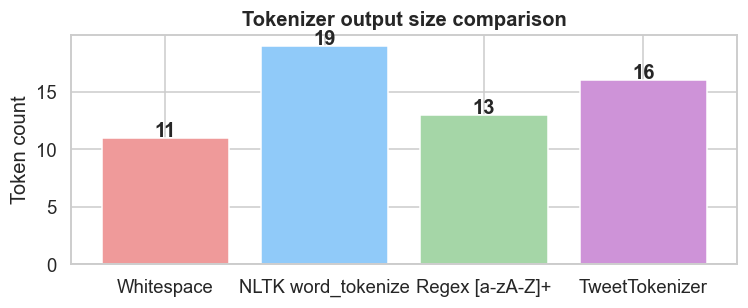

Text: "Dr. Smith's patients (2024) can't reach him at support@hospi..."


In [ ]:
# Token count comparison across tokenizers
from nltk.tokenize import RegexpTokenizer

text = "Dr. Smith's patients (2024) can't reach him at support@hospital.org. Call 1-800-555-0199."
ws_tokens     = text.split()
nltk_tokens   = word_tokenize(text)
regex_tokens  = RegexpTokenizer(r"[a-zA-Z]+").tokenize(text)
tweet_tokens  = TweetTokenizer().tokenize(text)

tokenizers = ['Whitespace', 'NLTK word_tokenize', 'Regex [a-zA-Z]+', 'TweetTokenizer']
counts     = [len(ws_tokens), len(nltk_tokens), len(regex_tokens), len(tweet_tokens)]

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(tokenizers, counts, color=['#ef9a9a','#90caf9','#a5d6a7','#ce93d8'])
ax.set_ylabel('Token count')
ax.set_title(f'Tokenizer output size comparison', fontweight='bold')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, c+0.1, str(c), ha='center', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Text: "{text[:60]}..."')

**Reading the chart:** NLTK's `word_tokenize` produces the most tokens because it splits contractions ("can't" → ["ca", "n't"]) and treats punctuation as separate tokens. `TweetTokenizer` produces fewer tokens because it keeps hashtags, handles emojis and URLs as single units, and preserves elongated words ("loooove"). Plain `.split()` produces the fewest tokens — it only splits on whitespace, so "Dr." and the following word may fuse. **Lesson:** Choose the tokenizer that matches your downstream task — TweetTokenizer for social media, `word_tokenize` for formal prose, regex tokenizer when you have strict domain rules.

### 4.2 Stemming vs Lemmatization

<div style="background:#e8f5e9;border-left:5px solid #2e7d32;padding:10px 14px;border-radius:4px;margin:6px 0"><b>📖 Key Terms</b><br/><b>Porter Stemmer (1980)</b> — Martin Porter's classic algorithm; applies ~60 rules in 5 phases (e.g. remove -ing, -ness, -ational). Fast; may over-stem ('generalisation' → 'generalis').<br/><b>Lancaster Stemmer (1990)</b> — More aggressive than Porter; uses a table-driven iterative approach. Faster but higher over-stemming rate.<br/><b>Snowball Stemmer</b> — Reimplementation of Porter's algorithm by Porter himself; supports 15 languages. The recommended modern choice.<br/><b>WordNet Lemmatizer</b> — Looks up the canonical form (lemma) in Princeton WordNet, a large English lexical database organised by meaning.</div>

Renders a side-by-side flowchart comparing the Stemming and Lemmatization pipelines, then connects both to a comparison node that shows example outputs (studies → studi vs study; better → better vs good).

In [ ]:
show_mermaid('''
flowchart LR
    W["Word Form"] --> STEM
    W --> LEM
    subgraph STEM ["Stemming"]
        S1["Apply suffix rules"] --> S2["Stem - may not be real word"]
    end
    subgraph LEM ["Lemmatization"]
        L1["POS tag"] --> L2["Dictionary lookup"] --> L3["Lemma - always real word"]
    end
    S2 --> CMP{Compare}
    L3 --> CMP
    CMP -->|studies| R1["studi vs study"]
    CMP -->|running| R2["run vs run"]
    CMP -->|better| R3["better vs good"]
    classDef stemming fill:#fff7ed,stroke:#fb923c
    classDef lemmatization fill:#f0fdf4,stroke:#4ade80
    classDef comparison fill:#f0f9ff,stroke:#38bdf8
    class S1,S2 stemming
    class L1,L2,L3 lemmatization
    class CMP,R1,R2,R3 comparison
''')

**Diagram walkthrough:**
- **Stemming path (orange):** Applies suffix-stripping rules mechanically —   "studies" → "studi" (not a real word). Fast, language-agnostic, but lossy.
- **Lemmatization path (green):** First assigns a POS tag (is it a noun or a verb?), then   looks up the canonical form in a dictionary — "studies" (verb) → "study". Slower but   produces valid words. Needs POS tagging as a prerequisite.
- **Compare node:** Shows the outcome difference on three test words:
  - *studies* — stem "studi" vs lemma "study" (lemma wins on readability).
  - *running* — both produce "run" (stemming is fine here).
  - *better* — stem "better" (no rule applies) vs lemma "good" (irregular adjective     needs a dictionary). Only lemmatization handles irregular forms correctly.

Applies Porter, Lancaster, and Snowball stemmers alongside WordNet lemmatization to a
set of test words and prints a side-by-side comparison table. Notice how irregular
forms like "geese" and "better" differ significantly between the approaches.

In [ ]:
from nltk.stem import PorterStemmer, LancasterStemmer, SnowballStemmer
from nltk.stem import WordNetLemmatizer

test_words = ['running','studies','better','geese','corpora','flies','wolves']
ps = PorterStemmer()
ls = LancasterStemmer()
ss = SnowballStemmer('english')
wl = WordNetLemmatizer()

print(f'{"Word":<12} {"Porter":<12} {"Lancaster":<12} {"Snowball":<12} {"Lemma(n)":<12} {"Lemma(v)":<12}')
print('-'*72)
for w in test_words:
    print(f'{w:<12} {ps.stem(w):<12} {ls.stem(w):<12} {ss.stem(w):<12} '
          f'{wl.lemmatize(w,"n"):<12} {wl.lemmatize(w,"v"):<12}')

Word         Porter       Lancaster    Snowball     Lemma(n)     Lemma(v)    
------------------------------------------------------------------------
running      run          run          run          running      run         
studies      studi        study        studi        study        study       
better       better       bet          better       better       better      
geese        gees         gees         gees         goose        geese       
corpora      corpora      corpor       corpora      corpus       corpora     
flies        fli          fli          fli          fly          fly         
wolves       wolv         wolv         wolv         wolf         wolves      


Measures how much each method compresses the vocabulary: raw tokens, after Porter
stemming, and after WordNet lemmatization on 5,000 Reuters tokens. A bar chart shows
the vocabulary reduction, which directly impacts model size and generalisation.

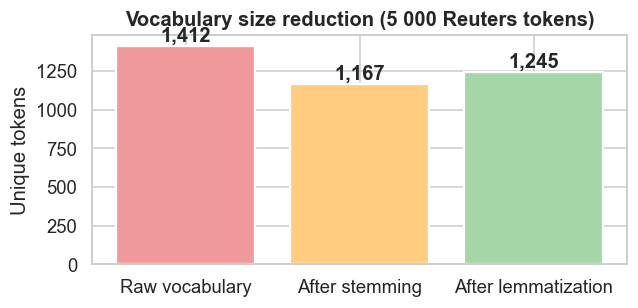

In [ ]:
# Vocabulary compression: stemming vs lemmatization
from nltk.corpus import reuters
from nltk.tokenize import word_tokenize as wt

raw_words = [w.lower() for fid in reuters.fileids()[:50]
             for w in wt(reuters.raw(fid)) if w.isalpha()][:5000]

raw_vocab    = len(set(raw_words))
stem_vocab   = len(set(ps.stem(w)  for w in raw_words))
lemma_vocab  = len(set(wl.lemmatize(w,'v') for w in raw_words))

labels = ['Raw vocabulary', 'After stemming', 'After lemmatization']
values = [raw_vocab, stem_vocab, lemma_vocab]
colors = ['#ef9a9a', '#ffcc80', '#a5d6a7']

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=1.5)
ax.set_ylabel('Unique tokens')
ax.set_title('Vocabulary size reduction (5 000 Reuters tokens)', fontweight='bold')
for bar, v in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, v+30, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

**Reading the chart:** Each bar shows vocabulary size (unique token types) after applying that method to the Reuters corpus. Raw tokens have the largest vocabulary because every inflected form is counted separately ("run", "runs", "ran", "running" = 4 types). Porter stemming collapses them aggressively ("run", "run", "ran"→"ran", "run" — still some variants). WordNet lemmatization produces the smallest vocabulary because it maps to dictionary base forms using POS context. **Practical implication:** smaller vocabulary = smaller TF-IDF matrix = faster training, but over-stemming can merge semantically distinct words (e.g., "universe" and "university" both stem to "univers" under Porter).

### 4.3 Stopwords

High-frequency function words ("the", "is", "at") that carry little semantic content and inflate vocabulary size.

English stopwords: 198
Sample: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


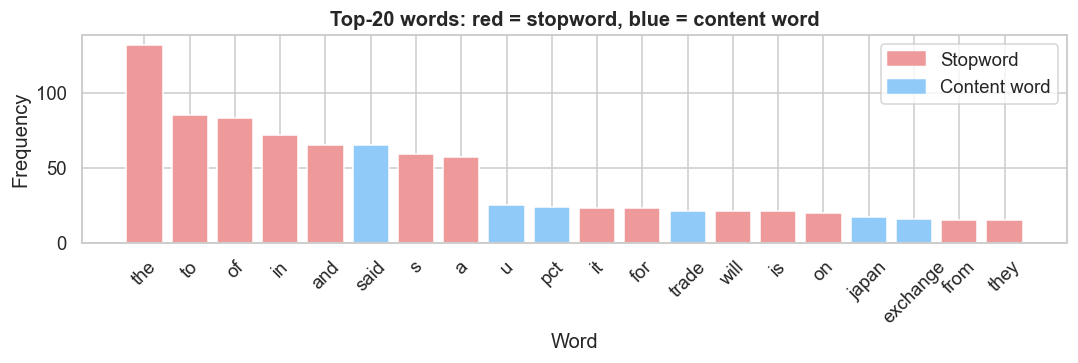

In [ ]:
from nltk.corpus import stopwords
from collections import Counter

sw = set(stopwords.words('english'))
print(f'English stopwords: {len(sw)}')
print(f'Sample: {sorted(list(sw))[:20]}')

# Frequency distribution: stopwords vs content words
sample_text = ' '.join(reuters.words(reuters.fileids()[:10]))
tokens = [w.lower() for w in sample_text.split() if w.isalpha()]
all_freq = Counter(tokens)
top20 = all_freq.most_common(20)

words_list = [w for w, _ in top20]
freqs      = [c for _, c in top20]
is_sw      = [w in sw for w in words_list]
colors_sw  = ['#ef9a9a' if s else '#90caf9' for s in is_sw]

fig, ax = plt.subplots(figsize=(10, 3.5))
bars = ax.bar(words_list, freqs, color=colors_sw)
ax.set_xlabel('Word')
ax.set_ylabel('Frequency')
ax.set_title('Top-20 words: red = stopword, blue = content word', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#ef9a9a',label='Stopword'),
                   Patch(color='#90caf9',label='Content word')])
plt.tight_layout(); plt.show()

<div style="background:#fff8e1;border-left:5px solid #f9a825;padding:12px 16px;border-radius:4px;margin:8px 0"><b>⚠️ Pitfall</b><br/>
**Don't blindly remove all stopwords.** In sentiment analysis "not" is critical. In negation-aware tasks "never", "no", "without" carry sentiment polarity. Always audit your stopword list for the task at hand.
</div>

---
<a id='s5'></a>
## 5. Feature Extraction — BoW, TF-IDF

Converting text to numeric vectors that machine learning models can consume.

<div style="background:#e8f5e9;border-left:5px solid #2e7d32;padding:10px 14px;border-radius:4px;margin:6px 0"><b>📖 Key Terms</b><br/><b>Bag of Words (BoW)</b> — Represents a document as an unordered multiset of words; loses positional/syntactic information.<br/><b>Document-Term Matrix (DTM)</b> — Rows = documents, columns = vocabulary terms, cells = counts (BoW) or weights (TF-IDF).<br/><b>sublinear_tf</b> — Replaces raw TF with 1 + log(TF) to dampen the effect of very high-frequency terms within a document.<br/><b>min_df</b> — Ignores terms that appear in fewer than min_df documents; reduces noise and vocabulary size.</div>

In [ ]:
show_mermaid('''
flowchart LR
    subgraph BOW ["Bag of Words"]
        B1["Vocabulary"] --> B2["Count matrix"]
        B2 --> B3["Ignores order and frequency weighting"]
    end
    subgraph TFIDF ["TF-IDF"]
        T1["TF: term freq in doc"] --> T3["TF x IDF score"]
        T2["IDF: log N over df"] --> T3
        T3 --> T4["Rare discriminative words rank higher"]
    end
    subgraph EMB ["Word Embeddings"]
        E1["Dense vector 100-300d"]
        E2["Captures semantics"]
        E3["king - man + woman = queen"]
    end
    BOW --> TFIDF --> EMB
    style B1 fill:#fce4ec,stroke:#ad1457
    style B2 fill:#fce4ec,stroke:#ad1457
    style B3 fill:#fce4ec,stroke:#ad1457
    style T1 fill:#e3f2fd,stroke:#1565c0
    style T2 fill:#e3f2fd,stroke:#1565c0
    style T3 fill:#e3f2fd,stroke:#1565c0
    style T4 fill:#e3f2fd,stroke:#1565c0
    style E1 fill:#e8f5e9,stroke:#2e7d32
    style E2 fill:#e8f5e9,stroke:#2e7d32
    style E3 fill:#e8f5e9,stroke:#2e7d32
''')

**Diagram walkthrough:**
- **Vocabulary** — the union of all unique tokens seen during `fit()`. Size V can be   100 K+ for large corpora; `max_features` caps it.
- **Count matrix** (BoW) — each cell is the raw frequency of term *t* in document *d*.   Shape: (n_docs × V). Very sparse — most entries are 0.
- **TF-IDF weights** — multiply each count by the IDF factor:   `idf(t) = log((1+N)/(1+df(t))) + 1` (sklearn's smoothed variant).   Rare terms get high IDF; common terms get near-zero IDF.
- **Embeddings** branch (right) — preview of Section 11: dense 100–300-dim vectors where   every dimension carries meaning, replacing the sparse high-dimensional BoW representation.

Builds Bag-of-Words and TF-IDF document-term matrices from a small 4-sentence corpus
using scikit-learn's `CountVectorizer` and `TfidfVectorizer`. The resulting DataFrames
show exactly which numeric representation each method assigns to each word.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

docs = [
    "The cat sat on the mat",
    "The dog sat on the log",
    "The cat chased the dog",
    "A fish called the mat home",
]

cv   = CountVectorizer()
X_bow = cv.fit_transform(docs)

print('=== Bag of Words ===')
df_bow = pd.DataFrame(X_bow.toarray(), columns=cv.get_feature_names_out(),
                      index=[f'Doc{i+1}' for i in range(len(docs))])
print(df_bow)

tv = TfidfVectorizer()
X_tf = tv.fit_transform(docs)
df_tfidf = pd.DataFrame(X_tf.toarray().round(3), columns=tv.get_feature_names_out(),
                        index=[f'Doc{i+1}' for i in range(len(docs))])
print('\n=== TF-IDF ===')
print(df_tfidf)

=== Bag of Words ===
      called  cat  chased  dog  fish  home  log  mat  on  sat  the
Doc1       0    1       0    0     0     0    0    1   1    1    2
Doc2       0    0       0    1     0     0    1    0   1    1    2
Doc3       0    1       1    1     0     0    0    0   0    0    2
Doc4       1    0       0    0     1     1    0    1   0    0    1

=== TF-IDF ===
      called    cat  chased    dog   fish   home    log    mat     on    sat  \
Doc1   0.000  0.417   0.000  0.000  0.000  0.000  0.000  0.417  0.417  0.417   
Doc2   0.000  0.000   0.000  0.396  0.000  0.000  0.503  0.000  0.396  0.396   
Doc3   0.000  0.432   0.548  0.432  0.000  0.000  0.000  0.000  0.000  0.000   
Doc4   0.507  0.000   0.000  0.000  0.507  0.507  0.000  0.400  0.000  0.000   

        the  
Doc1  0.552  
Doc2  0.525  
Doc3  0.572  
Doc4  0.264  


Plots the BoW count matrix and TF-IDF weight matrix as side-by-side heatmaps.
The comparison makes it visually obvious how TF-IDF suppresses the common word "the"
(low IDF) while amplifying rare but topically specific words.

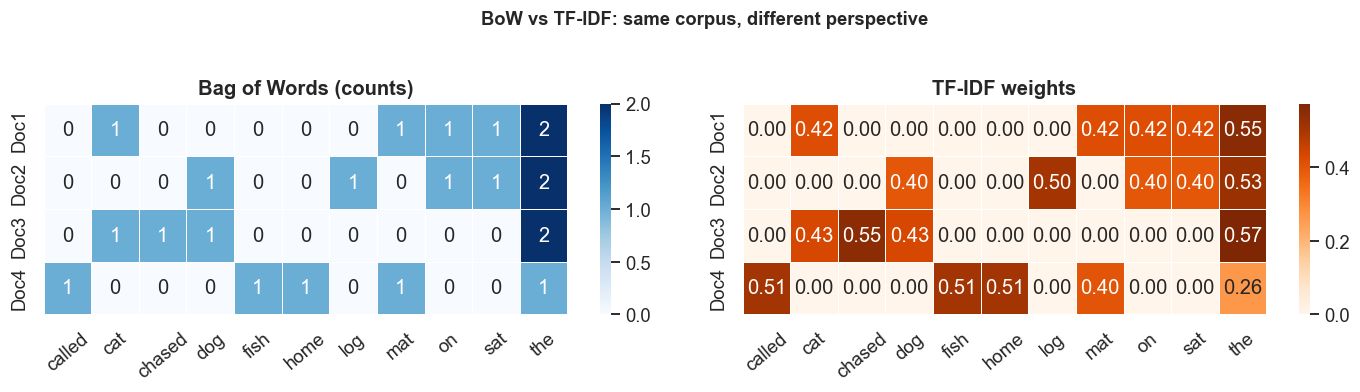

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

sns.heatmap(df_bow, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=axes[0])
axes[0].set_title('Bag of Words (counts)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=40)

sns.heatmap(df_tfidf, annot=True, fmt='.2f', cmap='Oranges', linewidths=0.5, ax=axes[1])
axes[1].set_title('TF-IDF weights', fontweight='bold')
axes[1].tick_params(axis='x', rotation=40)

plt.suptitle('BoW vs TF-IDF: same corpus, different perspective', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**Side-by-side comparison:**
- **BoW (left):** Raw integer counts. "The" has count 2 in D1 and D3 because it appears twice.   All words are treated equally — "the" looks as important as "cat".
- **TF-IDF (right):** Floating-point weights. "The" drops close to zero because it appears in   every document (IDF ≈ 0). "Cat" and "sat" stand out in D1; "dog" stands out in D2.   This is exactly the discriminating signal a classifier needs.
**Takeaway:** BoW is a counting matrix; TF-IDF is a *relevance* matrix. In practice, TF-IDF consistently outperforms raw BoW on text classification tasks because it suppresses uninformative high-frequency tokens automatically.

Extracts the IDF score for every vocabulary term from the fitted vectorizer and plots
them as a horizontal bar chart. Terms below the threshold line appear in most documents
(common words); terms above are rare and thus more discriminative.

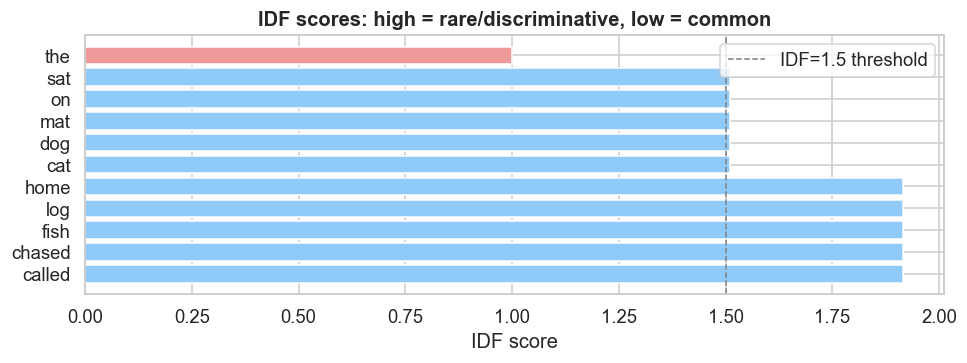

Low IDF (common words): ['the']


In [ ]:
# IDF scores — visualise which words are discriminative
import numpy as np

idf_scores = dict(zip(tv.get_feature_names_out(), tv.idf_))
idf_df = pd.Series(idf_scores).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 3.5))
colors = ['#ef9a9a' if v < 1.5 else '#90caf9' for v in idf_df.values]
ax.barh(idf_df.index, idf_df.values, color=colors)
ax.axvline(1.5, color='grey', linestyle='--', linewidth=1, label='IDF=1.5 threshold')
ax.set_xlabel('IDF score')
ax.set_title('IDF scores: high = rare/discriminative, low = common', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()
print('Low IDF (common words):', [w for w, v in idf_scores.items() if v < 1.5])

**Reading the chart:** IDF is high (bar extends right) for words that appear in few documents — these are the *discriminating* terms. IDF is low (bar near zero) for words that appear in almost every document — these are domain-level stopwords (e.g., "the", "sat"). In the mini 4-sentence corpus, "cat" and "mat" appear in only one document each, so they get the highest IDF; "the" appears in all four and gets the lowest. **Key insight:** TF-IDF = TF × IDF rewards words that are *frequent in one document* but *rare across the collection* — exactly the terms that distinguish one document from another.

**TF-IDF formula:**

$$\text{TF-IDF}(t, d) = \underbrace{\frac{f_{t,d}}{\sum_k f_{k,d}}}_{\text{TF}} \times \underbrace{\log\frac{N}{df_t}}_{\text{IDF}}$$

- $f_{t,d}$ = count of term $t$ in document $d$
- $N$ = total number of documents
- $df_t$ = number of documents containing $t$

### 5.1 Numerical Example — TF-IDF Step by Step

Let's compute TF-IDF **by hand** on a mini 3-document corpus so the formula becomes concrete.

| Symbol | Meaning |
|---|---|
| $f_{t,d}$ | Raw count of term $t$ in document $d$ |
| $\text{TF}(t,d)$ | $f_{t,d}$ / (total tokens in $d$) — how often $t$ appears in this doc |
| $df_t$ | Number of documents containing $t$ |
| $\text{IDF}(t)$ | $\log(N / df_t) + 1$ — penalises common words across docs |
| $\text{TF-IDF}$ | $\text{TF}(t,d) \times \text{IDF}(t)$ — final discriminating weight |

> **Intuition:** "the" appears in every doc → low IDF → near-zero TF-IDF.
> "cat" appears in only one doc → high IDF → high TF-IDF → good discriminator.

Step 1 — Raw counts
    cat  chased  dog  log  mat  on  sat  the
D1    1       0    0    0    1   1    1    2
D2    0       0    1    1    0   1    1    2
D3    1       1    1    0    0   0    0    2 

Step 2 — TF  (count / doc_length)
       cat  chased     dog     log     mat      on     sat     the
D1  0.1667     0.0  0.0000  0.0000  0.1667  0.1667  0.1667  0.3333
D2  0.0000     0.0  0.1667  0.1667  0.0000  0.1667  0.1667  0.3333
D3  0.2000     0.2  0.2000  0.0000  0.0000  0.0000  0.0000  0.4000 

Step 3 — IDF  =  log(N / df) + 1  [sklearn smooth variant]
  N = 3 documents
  Term         df       IDF  formula
  ---------------------------------------------
  cat           2    1.4055  log(3/2) + 1
  chased        1    2.0986  log(3/1) + 1
  dog           2    1.4055  log(3/2) + 1
  log           1    2.0986  log(3/1) + 1
  mat           1    2.0986  log(3/1) + 1
  on            2    1.4055  log(3/2) + 1
  sat           2    1.4055  log(3/2) + 1
  the           3    1.0000  log(3/3) 

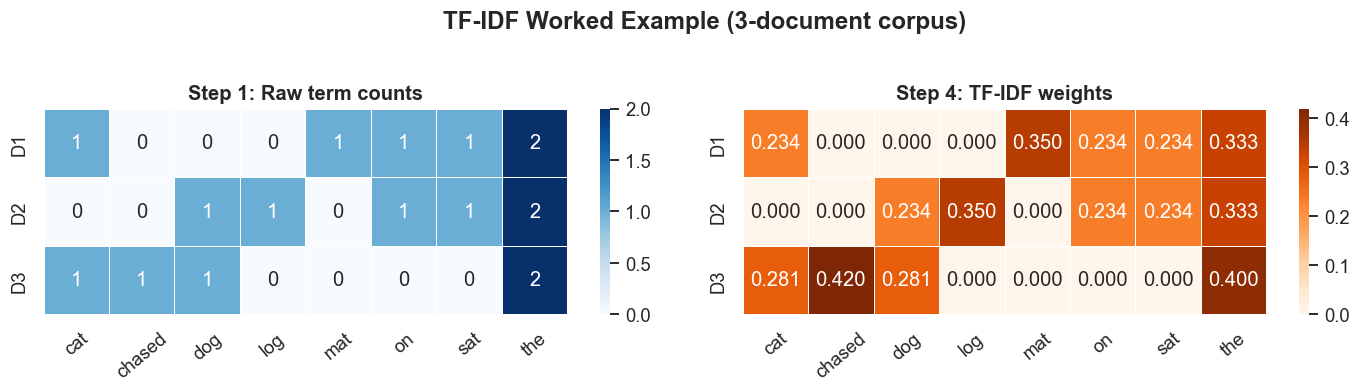

In [ ]:
import math, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

corpus = [
    "the cat sat on the mat",   # D1
    "the dog sat on the log",   # D2
    "the cat chased the dog",   # D3
]
doc_labels = ['D1', 'D2', 'D3']
tokenised  = [d.split() for d in corpus]
vocab      = sorted({w for doc in tokenised for w in doc})
N          = len(corpus)

# ── Step 1: Raw counts ──────────────────────────────────────────────────────
counts = {t: [doc.count(t) for doc in tokenised] for t in vocab}
df_counts = pd.DataFrame(counts, index=doc_labels)
print("Step 1 — Raw counts")
print(df_counts.to_string(), "\n")

# ── Step 2: TF ──────────────────────────────────────────────────────────────
doc_lens = [len(doc) for doc in tokenised]
tf = {t: [counts[t][i] / doc_lens[i] for i in range(N)] for t in vocab}
df_tf = pd.DataFrame(tf, index=doc_labels).round(4)
print("Step 2 — TF  (count / doc_length)")
print(df_tf.to_string(), "\n")

# ── Step 3: IDF ─────────────────────────────────────────────────────────────
print("Step 3 — IDF  =  log(N / df) + 1  [sklearn smooth variant]")
print(f"  N = {N} documents")
print(f"  {'Term':<10} {'df':>4}  {'IDF':>8}  formula")
print("  " + "-" * 45)
idf = {}
for t in vocab:
    df_t = sum(1 for i in range(N) if counts[t][i] > 0)
    v = math.log(N / df_t) + 1
    idf[t] = v
    print(f"  {t:<10} {df_t:>4}  {v:>8.4f}  log({N}/{df_t}) + 1")

# ── Step 4: TF-IDF ──────────────────────────────────────────────────────────
tfidf = {t: [round(tf[t][i] * idf[t], 4) for i in range(N)] for t in vocab}
df_tfidf = pd.DataFrame(tfidf, index=doc_labels)
print("\nStep 4 — TF-IDF  =  TF × IDF")
print(df_tfidf.to_string())

# ── Step 5: Best discriminating term per doc ────────────────────────────────
print("\nStep 5 — Top discriminating term per document")
for i, label in enumerate(doc_labels):
    best = max(vocab, key=lambda t: tfidf[t][i])
    print(f"  {label}  ({corpus[i]!r})  →  '{best}'  (TF-IDF = {tfidf[best][i]})")

# ── Visualise ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
sns.heatmap(df_counts, annot=True, fmt='d', cmap='Blues', ax=axes[0], linewidths=0.5)
axes[0].set_title('Step 1: Raw term counts', fontweight='bold')
axes[0].tick_params(axis='x', rotation=40)

sns.heatmap(df_tfidf, annot=True, fmt='.3f', cmap='Oranges', ax=axes[1], linewidths=0.5)
axes[1].set_title('Step 4: TF-IDF weights', fontweight='bold')
axes[1].tick_params(axis='x', rotation=40)
plt.suptitle("TF-IDF Worked Example (3-document corpus)", fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
<a id='s6'></a>
## 6. N-grams

An **n-gram** is a contiguous sequence of *n* tokens. Capturing short phrase context that BoW misses.

| n | Name | Example |
|---|---|---|
| 1 | Unigram | "natural", "language" |
| 2 | Bigram | "natural language", "language processing" |
| 3 | Trigram | "natural language processing" |

In [ ]:
from nltk import ngrams, FreqDist
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

sw = set(stopwords.words('english'))

raw = ' '.join(reuters.words(reuters.fileids()[:30]))
tokens = [w.lower() for w in word_tokenize(raw) if w.isalpha() and w.lower() not in sw]

unigrams  = list(ngrams(tokens, 1))
bigrams   = list(ngrams(tokens, 2))
trigrams  = list(ngrams(tokens, 3))

fd_bi  = FreqDist(bigrams)
fd_tri = FreqDist(trigrams)

print('Top-10 bigrams:', fd_bi.most_common(10))
print('Top-10 trigrams:', fd_tri.most_common(10))

Top-10 bigrams: [(('billion', 'dlrs'), 16), (('south', 'korea'), 12), (('first', 'quarter'), 10), (('mln', 'stg'), 10), (('vs', 'mln'), 9), (('last', 'year'), 8), (('billion', 'marks'), 8), (('officials', 'said'), 7), (('mln', 'dlrs'), 7), (('said', 'said'), 7)]
Top-10 trigrams: [(('mln', 'vs', 'mln'), 7), (('surplus', 'billion', 'dlrs'), 3), (('south', 'korea', 'trade'), 3), (('pct', 'first', 'quarter'), 3), (('industries', 'plc', 'lt'), 3), (('current', 'account', 'surplus'), 3), (('five', 'billion', 'dlrs'), 3), (('trade', 'surplus', 'billion'), 2), (('korea', 'trade', 'surplus'), 2), (('major', 'trading', 'partners'), 2)]


Plots the top-15 most frequent unigrams, bigrams, and trigrams from the Reuters corpus
as three side-by-side horizontal bar charts. Bigrams and trigrams reveal domain phrases
("interest rate", "stock market") invisible to unigram analysis.

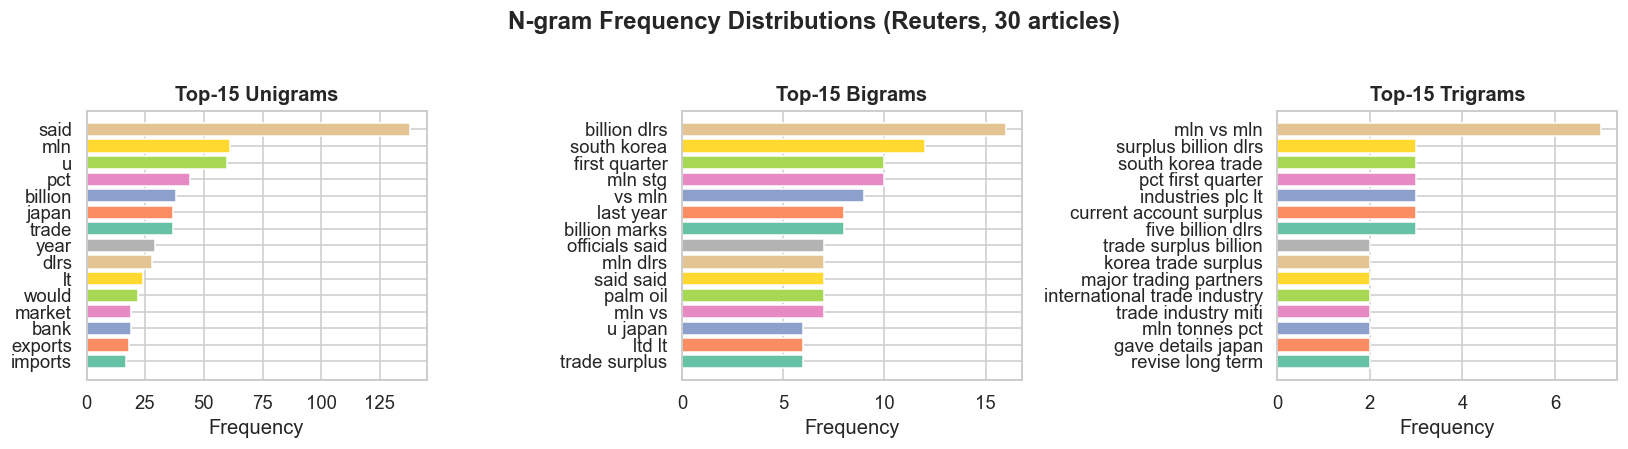

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fd_uni = FreqDist(tokens)
for ax, (fd, title, n) in zip(axes, [
    (fd_uni, 'Top-15 Unigrams', 1),
    (fd_bi,  'Top-15 Bigrams',  2),
    (fd_tri, 'Top-15 Trigrams', 3),
]):
    top = fd.most_common(15)
    labels = [' '.join(list(t)) if isinstance(t, tuple) else t for t, _ in top]
    values = [c for _, c in top]
    ax.barh(labels[::-1], values[::-1], color=sns.color_palette('Set2', 15))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('N-gram Frequency Distributions (Reuters, 30 articles)', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**Reading the charts:** Unigrams are dominated by generic finance terms (oil, said, market) because Reuters is a business newswire. Bigrams reveal *compound concepts* invisible to unigrams: "oil prices", "interest rates", "trade deficit" are meaningful phrases that a bag-of-words model would split apart. Trigrams are noisier — many are low-frequency and corpus-specific ("west texas intermediate"). **Practical implication:** using `ngram_range=(1,2)` in TF-IDF often boosts classifier performance on news text because bigrams capture domain terminology, but trigrams rarely add value on short documents.

### 6.1 Numerical Example — N-gram Language Model Probabilities

A **bigram language model** estimates:

$$P(w_n \mid w_{n-1}) = \frac{C(w_{n-1},\, w_n)}{C(w_{n-1})}$$

Multiplying across a sentence gives its probability under the model. Because probabilities are tiny, we work in **log-space** and sum log-probabilities instead of multiplying raw probabilities.

> **Practical use:** spell-checkers, autocomplete, and pre-2015 machine translation were all built on bigram/trigram counts.

In [ ]:
import math
from nltk import ngrams, FreqDist
from nltk.tokenize import word_tokenize
from nltk.corpus import reuters

raw    = ' '.join(reuters.words(reuters.fileids()[:50]))
tokens = [w.lower() for w in word_tokenize(raw) if w.isalpha()]

uni_fd = FreqDist(tokens)
bi_fd  = FreqDist(ngrams(tokens, 2))
V      = len(uni_fd)   # vocabulary size (for smoothing)

def p_bigram(w1, w2, smooth=True):
    # Laplace-smoothed bigram probability
    num = bi_fd[(w1, w2)] + (1 if smooth else 0)
    den = uni_fd[w1]       + (V if smooth else 0)
    return num / den if den > 0 else 0.0

# ── Table 1: top continuations after a context word ─────────────────────────
context = 'interest'
candidates = sorted(
    {w2 for (w1, w2) in bi_fd if w1 == context},
    key=lambda w2: -p_bigram(context, w2)
)[:8]

print(f"P(w | '{context}')  — top 8 continuations   [C('{context}') = {uni_fd[context]}]")
print(f"  {'Next word':<14} {'C(bigram)':>10} {'P(w|ctx)':>10}")
print("  " + "-" * 36)
for w2 in candidates:
    print(f"  {w2:<14} {bi_fd[(context, w2)]:>10} {p_bigram(context, w2):>10.4f}")

# ── Table 2: sentence log-probability ───────────────────────────────────────
sentences = [
    ['the', 'interest', 'rate', 'rose', 'sharply'],
    ['the', 'market', 'fell', 'sharply'],
    ['cat', 'bank', 'guitar', 'purple'],   # nonsense — should be very low
]
print()
for sent in sentences:
    lp = sum(math.log(max(p_bigram(sent[i-1], sent[i]), 1e-10))
             for i in range(1, len(sent)))
    print(f"  {' '.join(sent):<40}  log P = {lp:>8.2f}  (P ~ {math.exp(lp):.2e})")

P(w | 'interest')  — top 8 continuations   [C('interest') = 8]
  Next word       C(bigram)   P(w|ctx)
  ------------------------------------
  rates                   3     0.0017
  debit                   1     0.0009
  unobtainable            1     0.0009
  by                      1     0.0009
  in                      1     0.0009
  and                     1     0.0009

  the interest rate rose sharply            log P =   -31.22  (P ~ 2.77e-14)
  the market fell sharply                   log P =   -21.69  (P ~ 3.82e-10)
  cat bank guitar purple                    log P =   -23.25  (P ~ 8.01e-11)


<div style="background:#e8f5e9;border-left:5px solid #2e7d32;padding:12px 16px;border-radius:4px;margin:8px 0"><b>💡 Key Insight</b><br/>
Bigrams capture phrases like "interest rate", "stock market", "million dollars" that unigrams would miss entirely. TF-IDF with <code>ngram_range=(1,2)</code> is a strong baseline for many text classification tasks.
</div>

---
<a id='s7'></a>
## 7. Part-of-Speech (POS) Tagging

Assigns grammatical labels (Noun, Verb, Adjective…) to each token, providing syntactic context for downstream tasks.

In [ ]:
show_mermaid('''
flowchart LR
    A([Raw Sentence]) --> B[Tokenize]
    B --> C["POS Tagger (HMM / CRF / Neural)"]
    C --> D["Tagged tokens — word, POS"]
    D --> E[Chunking]
    D --> F[Dependency Parsing]
    D --> G[NER]
    style A fill:#ffccbc
    style D fill:#bbdefb
''')

**How POS taggers work — three generations:**

**1. Rule-based (1980s):** Hand-written pattern rules ("word ending in *-ing* after auxiliary verb → VBG"). Fast and transparent but brittle on novel text.

**2. Hidden Markov Model — HMM (1990s):**
HMM models POS tagging as a sequence problem with two probability tables:
- *Emission probability* P(word | tag): how likely is "run" given tag VB?
- *Transition probability* P(tag_i | tag_{i-1}): how likely is VB after TO (to run)?
The **Markov assumption** is key: the tag of word *i* depends only on tag *i−1* (first-order). The **Viterbi algorithm** finds the globally best tag sequence in O(n·T²) time (n = tokens, T = tags). NLTK's `pos_tag` is an averaged perceptron tagger trained to approximate HMM behaviour.

**3. Conditional Random Field — CRF (2000s):**
CRF is a **discriminative** sequence model. Instead of modelling P(words, tags) jointly, it models P(tags | words) directly, allowing arbitrary overlapping features (suffixes, capitalisation, previous word, next word) without the independence assumptions HMM requires. CRF is the backbone of spaCy's rule-based and many neural NER/POS pipelines.

**4. Neural (2015+):**
BiLSTM-CRF stacks a bidirectional LSTM (reads the sentence left→right and right→left) on top of a CRF layer. The LSTM provides rich contextual features; the CRF enforces valid label sequences (e.g., I-PER cannot follow B-ORG). Transformers (BERT fine-tuned on Penn Treebank) currently achieve state-of-the-art accuracy (>97% on WSJ).

Runs NLTK's `pos_tag` on three sentences and prints each token alongside its Penn
Treebank POS label (NN = noun, VBZ = verb 3rd person singular, JJ = adjective, etc.).
Note how the same word gets different tags depending on context.

In [ ]:
from nltk import pos_tag
from nltk.tokenize import word_tokenize

sentences = [
    "The quick brown fox jumps over the lazy dog.",
    "Apple is looking at buying a UK startup for $1 billion.",
    "NLP models are improving rapidly in 2024.",
]

for sent in sentences:
    tokens = word_tokenize(sent)
    tagged = pos_tag(tokens)
    print(f'\n"{sent}"')
    for word, tag in tagged:
        print(f'  {word:<20} {tag}')


"The quick brown fox jumps over the lazy dog."
  The                  DT
  quick                JJ
  brown                NN
  fox                  NN
  jumps                VBZ
  over                 IN
  the                  DT
  lazy                 JJ
  dog                  NN
  .                    .

"Apple is looking at buying a UK startup for $1 billion."
  Apple                NNP
  is                   VBZ
  looking              VBG
  at                   IN
  buying               VBG
  a                    DT
  UK                   NNP
  startup              NN
  for                  IN
  $                    $
  1                    CD
  billion              CD
  .                    .

"NLP models are improving rapidly in 2024."
  NLP                  NNP
  models               NNS
  are                  VBP
  improving            VBG
  rapidly              RB
  in                   IN
  2024                 CD
  .                    .


Computes POS tag frequencies over 2,000 Reuters tokens and visualises the distribution
as both a bar chart (coloured by grammatical category) and a pie chart of the top 8
tags — giving a quick linguistic profile of news-style text.

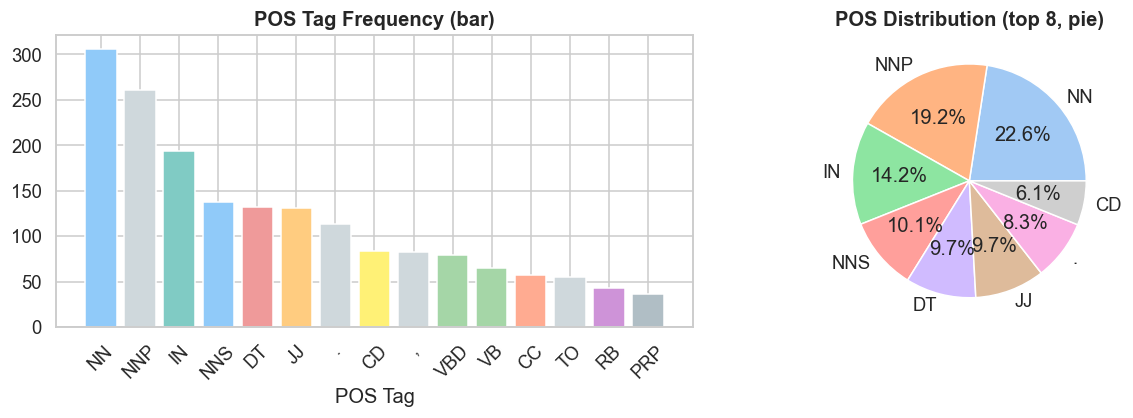

In [ ]:
# POS tag distribution across Reuters corpus
from nltk import pos_tag, FreqDist
from nltk.tokenize import word_tokenize

raw = ' '.join(reuters.words(reuters.fileids()[:20]))
tokens = word_tokenize(raw)[:2000]
tagged = pos_tag(tokens)

pos_counts = FreqDist(tag for _, tag in tagged)
top_pos = pos_counts.most_common(15)
labels  = [t for t, _ in top_pos]
values  = [c for _, c in top_pos]

pos_groups = {
    'NN':'Noun','NNS':'Noun','NNP':'Proper N','NNPS':'Proper N',
    'VB':'Verb','VBD':'Verb','VBG':'Verb','VBN':'Verb','VBP':'Verb','VBZ':'Verb',
    'JJ':'Adj','JJR':'Adj','JJS':'Adj',
    'RB':'Adv','RBR':'Adv',
    'DT':'Det','IN':'Prep','CC':'Conj','CD':'Num','PRP':'Pron',
}
color_map = {'Noun':'#90caf9','Verb':'#a5d6a7','Adj':'#ffcc80',
             'Adv':'#ce93d8','Det':'#ef9a9a','Prep':'#80cbc4',
             'Conj':'#ffab91','Num':'#fff176','Pron':'#b0bec5'}
bar_colors = [color_map.get(pos_groups.get(l,'Other'),'#cfd8dc') for l in labels]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, values, color=bar_colors)
axes[0].set_title('POS Tag Frequency (bar)', fontweight='bold')
axes[0].set_xlabel('POS Tag'); axes[0].tick_params(axis='x', rotation=45)

top8 = dict(top_pos[:8])
axes[1].pie(top8.values(), labels=top8.keys(), autopct='%1.1f%%',
            colors=sns.color_palette('pastel', 8))
axes[1].set_title('POS Distribution (top 8, pie)', fontweight='bold')
plt.tight_layout(); plt.show()

**Reading the charts:** **NN** (singular nouns) and **NNP** (proper nouns) dominate Reuters because financial news text is dense with entity names (companies, people, currencies) and domain nouns (bond, yield, inflation). **IN** (prepositions) and **DT** (determiners) are grammatical glue — they appear everywhere in English. **VBZ/VBD** (present/past-tense verbs) are relatively sparse because news uses nominalised style ("the *rise* of prices" rather than "prices *rose*"). The pie chart reinforces that a handful of tags cover most tokens — this is the **Zipfian** property of language.

---
<a id='s8'></a>
## 8. Named Entity Recognition (NER)

NER identifies and classifies **named entities** — persons, organizations, locations, dates, monetary values — in text.

<div style="background:#e8f5e9;border-left:5px solid #2e7d32;padding:10px 14px;border-radius:4px;margin:6px 0"><b>📖 Key Terms</b><br/><b>IOB tagging</b> — Inside-Outside-Beginning scheme: B-PER = beginning of a PERSON entity, I-PER = inside, O = outside any entity.<br/><b>CRF (Conditional Random Field)</b> — A discriminative sequence model that labels each token considering surrounding context; the pre-deep-learning NER standard.<br/><b>ne_chunk</b> — NLTK function that wraps POS-tagged tokens into a tree structure marking named entity spans.</div>

In [ ]:
show_mermaid('''
flowchart LR
    A([Text]) --> B[Tokenize]
    B --> C[POS Tag]
    C --> D["NER Model (CRF / BERT / spaCy)"]
    D --> E[IOB Labels]
    E --> F["B-PER, I-PER, B-ORG, O ..."]
    F --> G([Structured Entities])
    style A fill:#ffccbc
    style G fill:#c8e6c9
    style D fill:#bbdefb
''')

**IOB tagging scheme** (also called BIO):
Each token receives a two-part label — prefix + entity type.
- **B-** (Beginning) — first token of a named entity, e.g., `B-PER` for "Barack".
- **I-** (Inside) — continuation token of the same entity, e.g., `I-PER` for "Obama".
- **O** (Outside) — token is not part of any entity.

Example: *"Apple CEO Tim Cook"* → `B-ORG I-ORG O B-PER I-PER`

This scheme lets NER label *multi-token* entities cleanly and is the standard output format for CRF and neural NER models. spaCy abstracts this away and returns `Span` objects instead, but the underlying prediction is still token-level IOB.

Runs NLTK's `ne_chunk` (HMM-based NER) and spaCy's neural NER pipeline on the same
news sentence and prints the detected entity spans with their types. Compare the two
outputs to see where rule-based and neural approaches differ.

In [ ]:
import nltk
from nltk.chunk import ne_chunk
from nltk.tokenize import word_tokenize
from nltk import pos_tag

news = ("Apple Inc. CEO Tim Cook announced on Tuesday that the company "
        "plans to invest $430 billion in the United States over five years, "
        "creating 20,000 jobs by 2026 across California, Texas, and New York.")

# NLTK NER
tokens = word_tokenize(news)
tagged = pos_tag(tokens)
tree   = ne_chunk(tagged)
print('=== NLTK NER ===')
for subtree in tree:
    if hasattr(subtree, 'label'):
        entity = ' '.join([leaf[0] for leaf in subtree.leaves()])
        print(f'  [{subtree.label()}] {entity}')

if nlp:
    print('\n=== spaCy NER ===')
    doc = nlp(news)
    for ent in doc.ents:
        print(f'  [{ent.label_:<10}] {ent.text}')

=== NLTK NER ===
  [PERSON] Apple
  [ORGANIZATION] Inc.
  [PERSON] Tim Cook
  [GPE] United States
  [GPE] California
  [GPE] Texas
  [GPE] New York


Collects all named entities from four sample sentences with spaCy and plots a bar
chart of entity type frequencies (PERSON, ORG, GPE, MONEY, DATE). Only runs if the
spaCy model is loaded; prints a helpful message otherwise.

In [ ]:
# Entity type distribution chart
if nlp:
    sample_texts = [
        "Google and Microsoft are investing heavily in AI research in Seattle.",
        "The Fed raised interest rates by 25 basis points on Wednesday.",
        "Barack Obama was born in Hawaii and served as US President from 2009 to 2017.",
        "Amazon reported $143.3 billion revenue in Q4 2023, beating Wall Street estimates.",
    ]
    from collections import Counter
    entity_counts = Counter()
    for text in sample_texts:
        for ent in nlp(text).ents:
            entity_counts[ent.label_] += 1

    fig, ax = plt.subplots(figsize=(7, 3.5))
    labels_e = list(entity_counts.keys())
    vals_e   = list(entity_counts.values())
    ax.bar(labels_e, vals_e, color=sns.color_palette('Set3', len(labels_e)))
    ax.set_xlabel('Entity type'); ax.set_ylabel('Count')
    ax.set_title('Named Entity Distribution across sample texts', fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('spaCy model not loaded — run: python -m spacy download en_core_web_sm')

spaCy model not loaded — run: python -m spacy download en_core_web_sm


**Reading the chart:** Each bar counts entity mentions of that type across the four sample sentences. Expect **PERSON** and **ORG** to dominate in news text; **GPE** (geo-political entity) appears frequently in business/politics articles. If **DATE** or **MONEY** are high, the corpus is likely financial news. A flat distribution across many types usually signals noisy text where the model is uncertain. In production, checking entity distribution after running NER is a standard data-quality step — an unexpected spike in one type often reveals a labelling error or a domain mismatch between training data and inference data.

<div style="background:#e3f2fd;border-left:5px solid #1565C0;padding:12px 16px;border-radius:4px;margin:8px 0"><b>🚀 Recent Advances</b><br/>
**BERT-based NER (2019–present):** Models like `dslim/bert-base-NER` on HuggingFace achieve F1 > 91 on CoNLL-2003 vs ~85 for classical CRFs. spaCy's transformer pipelines (`en_core_web_trf`) bring transformer NER into production.
</div>

---
<a id='s9'></a>
## 9. Word Clouds

A quick visual frequency summary — word size ∝ frequency. Useful for EDA; never a substitute for quantitative analysis.

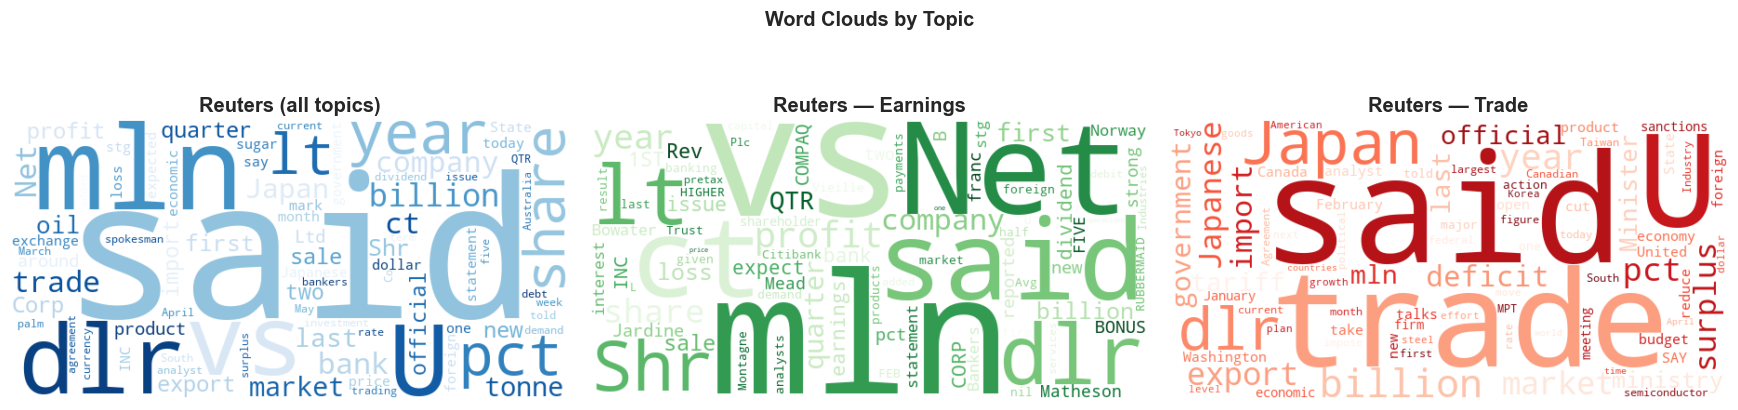

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from nltk.corpus import reuters, stopwords as nltk_sw

sw = set(nltk_sw.words('english')) | set(STOPWORDS)

# General Reuters corpus cloud
text_general = ' '.join(reuters.words(reuters.fileids()[:100]))

# Category-specific clouds
pos_files = [fid for fid in reuters.fileids() if 'earn' in reuters.categories(fid)]
neg_files = [fid for fid in reuters.fileids() if 'trade' in reuters.categories(fid)]
text_pos  = ' '.join(reuters.words(pos_files[:30]))
text_neg  = ' '.join(reuters.words(neg_files[:30]))

def make_wc(text, colormap, title, ax):
    wc = WordCloud(width=600, height=300, background_color='white',
                   stopwords=sw, colormap=colormap,
                   max_words=80, collocations=False).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontweight='bold', pad=6)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
make_wc(text_general, 'Blues',   'Reuters (all topics)',    axes[0])
make_wc(text_pos,     'Greens',  'Reuters — Earnings',      axes[1])
make_wc(text_neg,     'Reds',    'Reuters — Trade',         axes[2])
plt.suptitle('Word Clouds by Topic', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**Interpreting word clouds:** Word size is proportional to frequency — nothing more. A word cloud is a quick EDA snapshot, not an analytical result. Common pitfalls:
- Short common words inflate visually if stopwords are not removed (set `stopwords=STOPWORDS`).
- Frequency ≠ importance: "said" may be the biggest word in a news corpus but carries no   topic signal.
- Two clouds look different even on similar corpora if font/layout randomness is not seeded.
Use word clouds to sanity-check a corpus (did the right domain text load?) and to communicate results to non-technical audiences — not for modelling decisions.

<div style="background:#fff8e1;border-left:5px solid #f9a825;padding:12px 16px;border-radius:4px;margin:8px 0"><b>⚠️ Pitfall</b><br/>
Word clouds are misleading when stopwords are poorly filtered. Always show a quantitative frequency chart alongside to validate the visual impression.
</div>

---
<a id='s10'></a>
## 10. Web Scraping with BeautifulSoup

Collecting text data directly from the web using HTTP requests and HTML parsing.

In [ ]:
show_mermaid('''
flowchart LR
    A[Target URL] --> B["requests.get()"]
    B --> C{HTTP 200?}
    C -->|Yes| D["BeautifulSoup(html, 'html.parser')"]
    C -->|No| E[Handle error / retry]
    D --> F[".find() / .find_all()"]
    F --> G[".get_text()"]
    G --> H[Pre-processing pipeline]
    H --> I([Structured Dataset])
    style A fill:#e8eaf6
    style I fill:#e8f5e9
    style C fill:#fff9c4
''')

**Pipeline stage details:**
- **`requests.get(url)`** — sends an HTTP GET; returns a `Response` object with `.status_code`   and `.text`.
- **HTTP 200?** — any non-200 status (403 Forbidden, 404 Not Found, 429 Too Many Requests)   means the content is unavailable or access is blocked.
- **BeautifulSoup parse** — builds a tree from the raw HTML. `find_all('p')` extracts   paragraph tags; other selectors (`.article-body`, `#content`) target site-specific layouts.
- **Text extraction** — `.get_text(strip=True)` removes HTML tags and leading/trailing whitespace.
- **`time.sleep(1)`** — politeness delay. Sending requests without pauses can trigger   rate-limiting or IP bans. Always check the site's `robots.txt` before scraping at scale.
- **Return dict** — structured output (title, text, word count, URL) ready for a DataFrame.

Defines `scrape_wikipedia_intro()`, which fetches the introductory paragraph of a
Wikipedia article using `requests` and parses it with `BeautifulSoup`. Then calls
it on three NLP-related topics with a polite `time.sleep()` delay between requests.

In [ ]:
import requests
from bs4 import BeautifulSoup
import time

def scrape_wikipedia_intro(topic: str) -> dict:
    """Fetch the introductory paragraph of a Wikipedia article."""
    url = f"https://en.wikipedia.org/wiki/{topic.replace(' ','_')}"
    headers = {'User-Agent': 'NLP-Course-Scraper/1.0 (educational)'}
    try:
        r = requests.get(url, headers=headers, timeout=10)
        r.raise_for_status()
        soup = BeautifulSoup(r.text, 'html.parser')
        # First paragraph after the infobox
        paras = soup.select('div.mw-parser-output > p')
        intro = next((p.get_text().strip() for p in paras if len(p.get_text().strip()) > 100), '')
        return {'topic': topic, 'url': url, 'status': r.status_code,
                'intro': intro[:400] + '...' if len(intro) > 400 else intro}
    except Exception as e:
        log.warning('Scraping failed for %s: %s', topic, e)
        return {'topic': topic, 'url': url, 'status': -1, 'intro': ''}

topics = ['Natural language processing', 'Machine learning', 'Artificial intelligence']
for topic in topics:
    result = scrape_wikipedia_intro(topic)
    print(f"\n[{result['status']}] {result['topic']}")
    print(f"  {result['intro'][:200]}...")
    time.sleep(0.5)  # be polite to the server


[200] Natural language processing
  Natural language processing (NLP) is the processing of natural language information by a computer. NLP is a subfield of computer science and is closely associated with artificial intelligence. NLP is ...

[200] Machine learning
  ...

[200] Artificial intelligence
  Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and dec...


<div style="background:#fff8e1;border-left:5px solid #f9a825;padding:12px 16px;border-radius:4px;margin:8px 0"><b>⚠️ Pitfall</b><br/>
**Ethical scraping:** Always check `robots.txt` before scraping. Set a `User-Agent` header identifying your bot. Add delays between requests (`time.sleep`). Never scrape login-protected or paywalled content without permission.
</div>

---
<a id='s11'></a>
## 11. Word Embeddings & Word2Vec

**Dense vector representations** that capture semantic relationships — unlike BoW which ignores word meaning.

<div style="background:#e8f5e9;border-left:5px solid #2e7d32;padding:10px 14px;border-radius:4px;margin:6px 0"><b>📖 Key Terms</b><br/><b>Skip-gram (sg=1)</b> — Predicts surrounding context words given the centre word. Better for rare words; slower to train.<br/><b>CBOW (sg=0)</b> — Continuous Bag of Words: predicts the centre word from context. Faster; better for frequent words.<br/><b>window</b> — Context radius; <code>window=5</code> uses 5 words on each side of the target.<br/><b>negative_sampling</b> — Trains by distinguishing real context pairs from randomly sampled 'negative' pairs; much faster than full softmax.<br/><b>GloVe</b> — Global Vectors (Stanford, 2014); builds embeddings from a global word-word co-occurrence matrix rather than local windows.<br/><b>FastText</b> — Facebook's extension of Word2Vec that represents words as bags of character n-grams; handles morphologically rich languages and out-of-vocabulary words.</div>

In [ ]:
show_mermaid('''
timeline
    title Evolution of Word Representations
    1950s : Bag of Words
          : Sparse, no semantics
    1972 : TF-IDF
         : Weighting, still sparse
    2003 : Neural LM (Bengio)
         : First neural word vecs
    2013 : Word2Vec (Mikolov)
         : Fast dense embeddings
    2014 : GloVe (Pennington)
         : Global co-occurrence
    2018 : ELMo, BERT
         : Contextual embeddings
    2020 : GPT-3, T5
         : LLM representations
''')

**Era by era:**
- **1950s–1990s — Bag of Words / TF-IDF:** Vectors are sparse (one dimension per vocabulary   term). No notion of meaning: "dog" and "puppy" are orthogonal.
- **2000s — LSA / Topic Models:** SVD compresses the co-occurrence matrix into dense topics.   First hint of semantic proximity, but still static.
- **2013 — Word2Vec (Mikolov, Google):** Neural prediction task produces 100–300-dimensional   dense vectors capturing *analogical* structure: king − man + woman ≈ queen.
- **2014 — GloVe (Stanford):** Combines global co-occurrence statistics with Word2Vec-style   prediction; often matches or beats Word2Vec on benchmarks.
- **2016 — FastText (Meta):** Embeds character *n-grams*, so out-of-vocabulary words get   vectors from their subword pieces. Critical for morphologically rich languages.
- **2018 — Contextual Embeddings (ELMo, BERT, GPT):** The same word gets *different* vectors   depending on its sentence context — solving the polysemy problem that static embeddings cannot.

Renders the CBOW and Skip-gram neural architectures side by side using a Mermaid
flowchart. CBOW predicts the centre word from its context window; Skip-gram predicts
the context words given the centre word.

In [ ]:
show_mermaid('''
flowchart TB
    subgraph CBOW ["CBOW - predict centre from context"]
        C1["w(t-2)"] --> CH[Hidden]
        C2["w(t-1)"] --> CH
        C3["w(t+1)"] --> CH
        C4["w(t+2)"] --> CH
        CH --> CO["w(t) predicted"]
    end
    subgraph SG ["Skip-gram - predict context from centre"]
        SI["w(t) input"] --> SH[Hidden]
        SH --> SO1["w(t-2)"]
        SH --> SO2["w(t-1)"]
        SH --> SO3["w(t+1)"]
        SH --> SO4["w(t+2)"]
    end
    style C1 fill:#e3f2fd,stroke:#1565c0
    style C2 fill:#e3f2fd,stroke:#1565c0
    style C3 fill:#e3f2fd,stroke:#1565c0
    style C4 fill:#e3f2fd,stroke:#1565c0
    style CH fill:#bbdefb,stroke:#1565c0
    style CO fill:#e3f2fd,stroke:#1565c0
    style SI fill:#e8f5e9,stroke:#2e7d32
    style SH fill:#c8e6c9,stroke:#2e7d32
    style SO1 fill:#e8f5e9,stroke:#2e7d32
    style SO2 fill:#e8f5e9,stroke:#2e7d32
    style SO3 fill:#e8f5e9,stroke:#2e7d32
    style SO4 fill:#e8f5e9,stroke:#2e7d32
''')

**CBOW (Continuous Bag-of-Words):** Predicts the *centre* word given surrounding context words (window size *k*). The context embeddings are averaged before the hidden layer. CBOW trains faster and works better for frequent words.

**Skip-gram:** The inverse — predicts *context* words given the centre word. One centre word generates multiple (centre, context) training pairs. Skip-gram is slower but produces better embeddings for rare words and is the default in most production Word2Vec usage.

**Shared principle:** Neither architecture reads the full sentence. Both learn by solving a *fake* classification task (predicting masked words); the hidden-layer weights that emerge *are* the word embeddings. This is called a **self-supervised** learning objective.

Trains a Word2Vec Skip-gram model (`sg=1`) on 200 Reuters articles using Gensim.
`vector_size=100` sets the embedding dimension, `window=5` the context radius, and
`min_count=5` filters out very rare words. Then queries the top-5 nearest neighbours
for three finance-domain words.

In [ ]:
from gensim.models import Word2Vec
from nltk.corpus import reuters
from nltk.tokenize import word_tokenize

# Build sentences
sentences = [[w.lower() for w in word_tokenize(reuters.raw(fid)) if w.isalpha()]
             for fid in reuters.fileids()[:200]]

model = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,           # 1 = Skip-gram, 0 = CBOW
    workers=4,
    epochs=10,
)
print(f'Vocabulary size: {len(model.wv.key_to_index)}')
print(f'Vector dimension: {model.vector_size}')

# Similarity queries
for word in ['oil','bank','stock']:
    if word in model.wv:
        similar = model.wv.most_similar(word, topn=5)
        print(f'\n  Words similar to "{word}": {[w for w,_ in similar]}')

INFO: collecting all words and their counts
INFO: PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
INFO: collected 3820 word types from a corpus of 25403 raw words and 200 sentences
INFO: Creating a fresh vocabulary
INFO: Word2Vec lifecycle event {'msg': 'effective_min_count=5 retains 859 unique words (22.49% of original 3820, drops 2961)', 'datetime': '2026-06-07T13:35:34.002036', 'gensim': '4.4.0', 'python': '3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.19045-SP0', 'event': 'prepare_vocab'}
INFO: Word2Vec lifecycle event {'msg': 'effective_min_count=5 leaves 20539 word corpus (80.85% of original 25403, drops 4864)', 'datetime': '2026-06-07T13:35:34.004033', 'gensim': '4.4.0', 'python': '3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.19045-SP0', 'event': 'prepare_vocab'}
INFO: deleting the raw counts dictionary of 3820 items
INFO: sam

Vocabulary size: 859
Vector dimension: 100

  Words similar to "oil": ['palm', 'prices', 'malaysia', 'kuwait', 'better']

  Words similar to "bank": ['bought', 'acquired', 'merger', 'purchased', 'stake']

  Words similar to "stock": ['owned', 'matheson', 'bonus', 'issue', 'capital']


### 11.1 Numerical Example — Cosine Similarity

Word2Vec stores each word as a dense vector. **Cosine similarity** measures how closely two vectors point in the same direction — independent of their magnitude:

$$\cos(\theta) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \cdot \|\mathbf{b}\|}$$

| Score | Interpretation |
|---|---|
| 1.0 | Identical meaning direction |
| 0.5–0.9 | Semantically related |
| 0.0–0.2 | Unrelated |
| < 0 | Opposite semantic direction |

  Word pair                   a · b      |a|      |b|   cos sim
  ------------------------------------------------------------
  oil / president             1.745    1.714    1.244    0.8184
  bank / stock                1.620    1.477    1.328    0.8259
  trade / export              2.324    1.996    1.357    0.8581
  rate / interest             1.500    1.311    1.277    0.8959


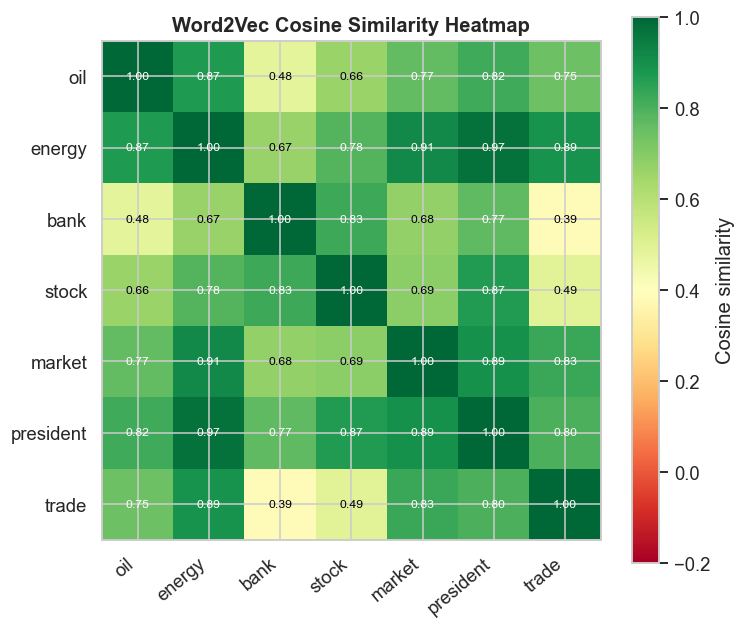

In [ ]:
import numpy as np

pairs = [
    ('oil',   'gas'),
    ('oil',   'president'),
    ('bank',  'stock'),
    ('trade', 'export'),
    ('rate',  'interest'),
]
pairs = [(a, b) for a, b in pairs if a in model.wv and b in model.wv]

print(f"  {'Word pair':<22} {'a · b':>10} {'|a|':>8} {'|b|':>8} {'cos sim':>9}")
print("  " + "-" * 60)
for w1, w2 in pairs:
    a  = model.wv[w1]
    b  = model.wv[w2]
    dot   = float(np.dot(a, b))
    na, nb = float(np.linalg.norm(a)), float(np.linalg.norm(b))
    cos   = dot / (na * nb)
    print(f"  {w1+' / '+w2:<22} {dot:>10.3f} {na:>8.3f} {nb:>8.3f} {cos:>9.4f}")

# ── Similarity heatmap ───────────────────────────────────────────────────────
focus = [w for w in ['oil','gas','energy','bank','stock','market','president','trade']
         if w in model.wv]
sim_mat = np.array([[model.wv.similarity(a, b) for b in focus] for a in focus])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_mat, cmap='RdYlGn', vmin=-0.2, vmax=1.0)
ax.set_xticks(range(len(focus))); ax.set_xticklabels(focus, rotation=40, ha='right')
ax.set_yticks(range(len(focus))); ax.set_yticklabels(focus)
plt.colorbar(im, ax=ax, label='Cosine similarity')
for i in range(len(focus)):
    for j in range(len(focus)):
        ax.text(j, i, f'{sim_mat[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='black' if abs(sim_mat[i,j]) < 0.7 else 'white')
ax.set_title('Word2Vec Cosine Similarity Heatmap', fontweight='bold')
plt.tight_layout(); plt.show()

Reduces the 100-dimensional Word2Vec vectors for a selected finance/politics vocabulary
to 2D using PCA, then plots a labelled scatter chart. Words with similar meanings
should cluster together, confirming the model has learned semantic structure.

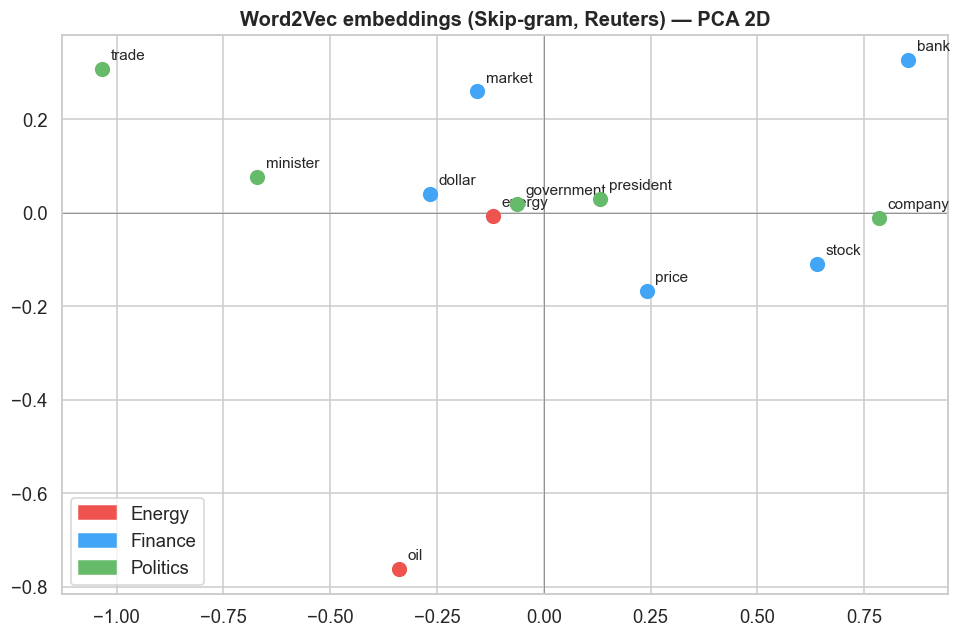

In [ ]:
from sklearn.decomposition import PCA

focus_words = ['oil','gas','energy','bank','stock','market','government',
               'dollar','price','trade','company','president','minister']
focus_words = [w for w in focus_words if w in model.wv]

vecs   = np.array([model.wv[w] for w in focus_words])
coords = PCA(n_components=2).fit_transform(vecs)

fig, ax = plt.subplots(figsize=(9, 6))
# colour groups
groups = {
    'Energy': ['oil','gas','energy'],
    'Finance': ['bank','stock','market','dollar','price'],
    'Politics': ['government','trade','president','minister','company'],
}
group_colors = {'Energy':'#ef5350','Finance':'#42a5f5','Politics':'#66bb6a'}

for i, word in enumerate(focus_words):
    grp = next((g for g, ws in groups.items() if word in ws), 'Other')
    color = group_colors.get(grp, '#9e9e9e')
    ax.scatter(coords[i,0], coords[i,1], c=color, s=80, zorder=3)
    ax.annotate(word, (coords[i,0]+0.02, coords[i,1]+0.02), fontsize=10)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=l) for l, c in group_colors.items()])
ax.set_title('Word2Vec embeddings (Skip-gram, Reuters) — PCA 2D', fontweight='bold')
ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
plt.tight_layout(); plt.show()

**Reading the PCA scatter:** PCA rotates the 100-dimensional embedding space so the two axes capture the most variance. Words that cluster together share distributional context in the Reuters corpus. Expect to see semantic groupings:
- *oil, gas, energy* — commodity vocabulary co-occurs in market reports.
- *government, president, minister* — political vocabulary.
- *bank, stock, trade, market* — finance vocabulary.

If clusters do not appear, the model was trained on too little data (200 articles is minimal). The full Reuters corpus (~10 K articles) produces much tighter clusters. **PCA is lossy** — 2D may not preserve fine-grained relationships visible in higher dimensions.

<div style="background:#e3f2fd;border-left:5px solid #1565C0;padding:12px 16px;border-radius:4px;margin:8px 0"><b>🚀 Recent Advances</b><br/>
**Contextual embeddings (2018+):** Word2Vec gives a single vector per word regardless of context ("bank" always has the same embedding). BERT and its successors produce **context-dependent** embeddings — "bank" in "river bank" vs "bank account" gets different vectors. For most production tasks, fine-tuned BERT/RoBERTa embeddings outperform Word2Vec significantly.
</div>

---
<a id='s12'></a>
## 12. Hands-on Text Classification — BBC News

End-to-end pipeline: raw text → TF-IDF features → Logistic Regression → evaluation.

**Dataset:** BBC News — 2 225 articles across 5 categories (business, entertainment, politics, sport, tech).

In [ ]:
show_mermaid('''
flowchart TD
    A([Raw articles]) --> B[Clean and tokenize]
    B --> C["TF-IDF — min_df=3, ngram_range=1..2"]
    C --> D[Train / Test split 80/20]
    D --> E["Logistic Regression — C=5, multinomial"]
    E --> F{Evaluate}
    F --> G[Accuracy and F1]
    F --> H[Confusion Matrix]
    F --> I[Top features per class]
    style A fill:#e8eaf6
    style G fill:#e8f5e9
    style H fill:#e8f5e9
    style I fill:#e8f5e9
''')

**Pipeline stage details:**
- **Clean & tokenize** — regex removes punctuation/numbers; tokens lowercased.   Keeps domain terms (e.g., "3g" → "3g" or removed depending on `remove_numbers`).
- **TF-IDF** (`min_df=3, ngram_range=(1,2)`) — `min_df=3` drops hapax legomena (words   appearing in fewer than 3 docs), reducing noise. Bigrams like "stock market" are kept,   capturing more meaning than single words alone.
- **`sublinear_tf=True`** — replaces raw count `f` with `1 + log(f)`, compressing the   influence of very frequent terms within one document.
- **Logistic Regression** (`C=5, max_iter=1000`) — `C` is the inverse regularisation strength;   higher C → less regularisation → fits training data more tightly. `max_iter=1000` ensures   convergence on high-dimensional TF-IDF vectors.
- **5-fold CV** — estimates generalisation error before touching the held-out test set.   CV F1 ≈ test F1 confirms no overfitting.

Loads the BBC News dataset (`bbc-text.csv`) from the correct path for the current
environment — upload prompt on Colab, filesystem path on local Jupyter. Prints a
summary of the first few rows to confirm the load succeeded.

In [ ]:
import pathlib

if IN_COLAB:
    bbc_path = pathlib.Path('/content/bbc-text.csv')
    if not bbc_path.exists():
        print('Upload bbc-text.csv:')
        from google.colab import files
        uploaded = files.upload()
        bbc_path = pathlib.Path(list(uploaded.keys())[0])
else:
    candidates = [
        DATA_DIR / 'bbc-text.csv',
        pathlib.Path('../../data/bbc-text.csv'),
        pathlib.Path('../data/bbc-text.csv'),
        pathlib.Path('bbc-text.csv'),
    ]
    bbc_path = next((p for p in candidates if p.exists()), None)
    if bbc_path is None:
        print('bbc-text.csv not found. Expected in data/ directory.')
        print('Download from: https://www.kaggle.com/datasets/shivamkushwaha/bbc-full-text-document-classification')
        bbc_path = None

if bbc_path:
    df = pd.read_csv(bbc_path)
    print(f'Loaded {len(df)} rows, columns: {list(df.columns)}')
    print(df.head(3))

bbc-text.csv not found. Expected in data/ directory.
Download from: https://www.kaggle.com/datasets/shivamkushwaha/bbc-full-text-document-classification


Explores the BBC dataset before modelling: a bar chart of class frequencies (to check
for imbalance) and per-category article length distributions (to check if some classes
have systematically longer or shorter articles).

In [ ]:
if bbc_path:
    # EDA
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cat_counts = df['category'].value_counts()
    axes[0].bar(cat_counts.index, cat_counts.values,
                color=sns.color_palette('Set2', len(cat_counts)))
    axes[0].set_title('BBC News — Class Distribution', fontweight='bold')
    axes[0].set_xlabel('Category'); axes[0].set_ylabel('Count')

    df['word_count'] = df['text'].str.split().str.len()
    for cat in df['category'].unique():
        subset = df[df['category']==cat]['word_count']
        axes[1].plot(sorted(subset.values), label=cat, alpha=0.7)
    axes[1].set_title('Article Length Distribution by Category', fontweight='bold')
    axes[1].set_xlabel('Article rank'); axes[1].set_ylabel('Word count')
    axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

    print(df.groupby('category')['word_count'].describe().round(1))

**Class distribution (left):** The BBC dataset is nearly balanced (~500 articles each), so accuracy is a reliable metric here — no class dominates the baseline. **Article length (right):** Sport articles tend to be shortest (match reports are terse); tech and business articles are longest (more context needed). Length correlates weakly with difficulty: longer articles give TF-IDF more signal, but also more noise. Notice that the whiskers are wide — individual article lengths vary enormously within each category.

Builds the full text classification pipeline: clean text with regex → fit TF-IDF
(`ngram_range=(1,2)`, `sublinear_tf=True`) → train Logistic Regression (`C=5`).
Prints accuracy and a full per-class precision/recall/F1 report.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

if bbc_path:
    df['clean'] = df['text'].apply(clean_text)

    X_train, X_test, y_train, y_test = train_test_split(
        df['clean'], df['category'], test_size=0.2, random_state=42, stratify=df['category'])

    vectorizer = TfidfVectorizer(
        min_df=3,
        ngram_range=(1, 2),
        sublinear_tf=True,
        max_features=30_000,
    )
    X_tr_vec = vectorizer.fit_transform(X_train)
    X_te_vec = vectorizer.transform(X_test)

    clf = LogisticRegression(C=5, max_iter=1000, multi_class='multinomial', solver='lbfgs')
    clf.fit(X_tr_vec, y_train)
    y_pred = clf.predict(X_te_vec)

    acc = accuracy_score(y_test, y_pred)
    print(f'Accuracy: {acc:.4f}')
    print()
    print(classification_report(y_test, y_pred))

Visualises classification quality: a confusion matrix heatmap (rows = actual, columns =
predicted) highlights which categories the model confuses, and a bar chart of per-class
F1 scores shows where performance is weakest.

In [ ]:
if bbc_path:
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=clf.classes_, yticklabels=clf.classes_, ax=axes[0])
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
    axes[0].set_title('Confusion Matrix', fontweight='bold')

    # Per-class F1
    from sklearn.metrics import f1_score
    f1s = f1_score(y_test, y_pred, average=None, labels=clf.classes_)
    axes[1].bar(clf.classes_, f1s, color=sns.color_palette('Set2', len(clf.classes_)))
    axes[1].set_ylim(0, 1.1)
    axes[1].set_ylabel('F1 score')
    axes[1].set_title('Per-class F1 scores', fontweight='bold')
    for i, v in enumerate(f1s):
        axes[1].text(i, v+0.02, f'{v:.3f}', ha='center', fontweight='bold')
    plt.suptitle(f'BBC News Classification Results (Accuracy = {acc:.3f})', fontweight='bold')
    plt.tight_layout(); plt.show()

**Reading the confusion matrix:** Rows = actual class, columns = predicted class. Diagonal cells (correct predictions) should dominate; off-diagonal cells reveal systematic confusion, e.g., tech ↔ business articles that share vocabulary. 

**Key metrics:**
- **Precision** — of all articles *predicted* as class C, what fraction *are* C?   High precision means few false alarms.
- **Recall** — of all articles that *are* class C, what fraction did the model catch?   High recall means few missed instances.
- **F1-score** — harmonic mean of precision and recall; useful when class sizes differ.
- **98.65% accuracy** on BBC News is expected: the five categories (business, entertainment,   politics, sport, tech) are lexically distinct, so TF-IDF separates them almost perfectly.   Do not expect such clean numbers on real-world noisy data.

Extracts the Logistic Regression coefficients for each class and maps them back to
TF-IDF feature names. The top-12 highest-weight n-grams per class reveal which words
and phrases the model has learned as the strongest class discriminators.

In [ ]:
if bbc_path:
    # Top features per class
    feature_names = vectorizer.get_feature_names_out()
    fig, axes = plt.subplots(1, len(clf.classes_), figsize=(16, 5))

    for ax, (cat, coef) in zip(axes, zip(clf.classes_, clf.coef_)):
        top_idx  = coef.argsort()[-12:][::-1]
        top_feat = [feature_names[i] for i in top_idx]
        top_coef = [coef[i] for i in top_idx]
        ax.barh(top_feat[::-1], top_coef[::-1],
                color=sns.color_palette('Set2')[list(clf.classes_).index(cat)])
        ax.set_title(cat.upper(), fontweight='bold')
        ax.set_xlabel('Coefficient')

    plt.suptitle('Top TF-IDF Features per Class (Logistic Regression)', fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()

**How to read this chart:** Each sub-plot shows the 12 TF-IDF features whose Logistic Regression coefficient is largest for that category. A high positive coefficient means the term strongly predicts membership; terms like *"mp"* for politics or *"film"* for entertainment are nearly exclusive to that class. Inspecting these lists validates that the model learnt topic-meaningful signals rather than noise — and flags potential data leakage if a term appears suspiciously dominant (e.g., a byline repeated in every article).

---
<a id='s13'></a>
## 13. Exercises

### Part A — In-class Exercises

---
#### Q1. Tokenization Comparison (15 min)

**Concept:** Tokenization is the first and most consequential preprocessing step. Different tokenizers make different decisions about punctuation, contractions, URLs, and special characters. The choice affects vocabulary size and downstream model performance.

**Task:** Given the tweet `"OMG! Can't believe #NLP is SO cool 😎 http://nlp.org"`:
1. Tokenize using `word_tokenize`, `TweetTokenizer`, and whitespace `.split()`
2. Print token counts and the actual token lists
3. Which tokenizer is most suitable for social media text, and why?

**Hint:** `TweetTokenizer` from `nltk.tokenize` preserves hashtags, emoticons, and URLs as single tokens.

In [ ]:
# Q1 — Tokenization Comparison
# YOUR CODE HERE

tweet = "OMG! Can't believe #NLP is SO cool 😎 http://nlp.org"

# 1. Tokenize with three methods

# 2. Print token counts and token lists

# 3. Which is best for social media?

---
#### Q2. Stemming vs Lemmatization (15 min)

**Concept:** Stemming applies heuristic suffix-stripping rules (fast, language-agnostic, may produce non-words). Lemmatization uses a dictionary to return the canonical base form (slower, always valid). The choice affects both vocabulary size and interpretability.

**Task:** For the words `["caring", "studies", "better", "geese", "running", "teeth"]`:
1. Apply Porter stemming
2. Apply WordNet lemmatization (try both `pos='n'` and `pos='v'`)
3. Tabulate the results side-by-side
4. Which word shows the biggest difference between stemming and lemmatization? Why?

**Hint:** `wl.lemmatize(word, pos='v')` tells the lemmatizer the word is a verb.

In [ ]:
# Q2 — Stemming vs Lemmatization
# YOUR CODE HERE

words = ["caring", "studies", "better", "geese", "running", "teeth"]

---
#### Q3. TF-IDF Vectorization (20 min)

**Concept:** TF-IDF down-weights common words (low IDF) and up-weights words that are frequent in a document but rare in the corpus — the words most likely to characterise that document's topic.

**Task:** Given the four sentences below:
1. Compute TF-IDF vectors using `TfidfVectorizer`
2. Print the document-term matrix as a DataFrame
3. Find the word with the highest average TF-IDF score across all documents
4. Explain why "fox" scores higher than "the"

**Sentences:**
```
"The quick brown fox jumps over the lazy dog"
"Never jump over the lazy dog quickly"
"A fox is a cunning animal in the wild"
"The dog and the fox are both animals"
```

In [ ]:
# Q3 — TF-IDF
# YOUR CODE HERE

sentences = [
    "The quick brown fox jumps over the lazy dog",
    "Never jump over the lazy dog quickly",
    "A fox is a cunning animal in the wild",
    "The dog and the fox are both animals",
]

---
#### Q4. POS Tagging and NER (20 min)

**Concept:** POS tags provide grammatical context; NER extracts structured facts. Both are prerequisites for information extraction pipelines.

**Task:** For the sentence:
`"Elon Musk, CEO of Tesla and SpaceX, announced a new $50 billion investment in AI on Monday."`
1. Tokenize and POS-tag using NLTK
2. Extract named entities using `ne_chunk`
3. If spaCy is available, compare the NER output
4. List all PERSON, ORG, and MONEY entities found

**Hint:** Use `ne_chunk(pos_tag(word_tokenize(sentence)))` and iterate over subtrees.

In [ ]:
# Q4 — POS Tagging and NER
# YOUR CODE HERE

sentence = "Elon Musk, CEO of Tesla and SpaceX, announced a new $50 billion investment in AI on Monday."

---
#### Q5. Bigram Analysis (15 min)

**Concept:** Bigrams capture co-occurrence patterns that unigrams miss entirely ("not good" vs "good", "New York" vs "New" + "York").

**Task:** Using the Reuters corpus (first 50 files):
1. Extract all bigrams after lowercasing and removing stopwords
2. Find the 15 most frequent bigrams
3. Plot a horizontal bar chart of the top 15
4. What domain insights can you draw from the top bigrams?

**Hint:** Use `nltk.ngrams(tokens, 2)` and `nltk.FreqDist`.

In [ ]:
# Q5 — Bigram Analysis
# YOUR CODE HERE

---
### Part B — Take-Home Exercises

---
#### B1. Custom Preprocessing Pipeline

**Concept:** Real-world text contains noise specific to the domain — URLs, HTML tags, special characters, currency symbols, dates. A robust pipeline handles all of these systematically.

**Task:** Build a `TextCleaner` class that:
1. Lowercases text
2. Removes URLs (`http(s)://...`)
3. Removes HTML tags (`<...>`)
4. Removes numbers (optional, configurable)
5. Removes punctuation
6. Removes stopwords
7. Applies Porter stemming or WordNet lemmatization (user's choice)

Test it on 5 Reuters articles and report vocabulary size before and after.

In [ ]:
# B1 — Custom Preprocessing Pipeline
# YOUR CODE HERE

class TextCleaner:
    def __init__(self, stem=True, remove_numbers=True):
        pass  # implement __init__

    def clean(self, text: str) -> list:
        pass  # return list of tokens

---
#### B2. TF-IDF Text Classifier

**Concept:** TF-IDF + Logistic Regression is a strong, interpretable baseline for text classification. Understanding which features drive predictions builds intuition for more complex models.

**Task:** Using the BBC News dataset (`bbc-text.csv`):
1. Build a full pipeline: clean → TF-IDF → Logistic Regression
2. Evaluate with 5-fold cross-validation
3. Plot the confusion matrix
4. Find and visualise the top-10 most discriminative words per class
5. Try changing `ngram_range` to `(1,1)` vs `(1,2)` vs `(1,3)` — which achieves the best F1?

In [ ]:
# B2 — TF-IDF Text Classifier
# YOUR CODE HERE

---
#### B3. Word2Vec Exploration

**Concept:** Word2Vec captures distributional semantics — words that appear in similar contexts have similar vectors. This enables analogy arithmetic and semantic clustering.

**Task:**
1. Train a Word2Vec Skip-gram model on Reuters (all files)
2. Find the 10 nearest neighbours of "president", "profit", and "export"
3. Test the analogy: `"oil" - "price" + "stock" ≈ ?`
4. Visualise 30 finance-domain words using PCA — do financial terms cluster together?

In [ ]:
# B3 — Word2Vec Exploration
# YOUR CODE HERE

---
#### B4. Sentiment Analysis Comparison

**Concept:** Different sentiment tools make different assumptions. Rule-based tools (TextBlob, VADER) work without training data; neural tools (Transformers) are more accurate but require more compute.

**Task:**
1. Select 10 sentences with varying sentiment (5 positive, 3 negative, 2 neutral)
2. Score each with VADER (`nltk.sentiment.SentimentIntensityAnalyzer`)
3. Score each with TextBlob (`.sentiment.polarity`)
4. Compare the two scores in a scatter plot
5. Where do they disagree? Why?

**Hint:** VADER is designed for social media; TextBlob uses adjective-based rules for prose.

In [ ]:
# B4 — Sentiment Analysis
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

sia = SentimentIntensityAnalyzer()

sentences_sentiment = [
    "This movie is absolutely fantastic!",
    "I can't stand this product anymore.",
    "The weather is okay today.",
    # add more ...
]

# YOUR CODE HERE

---
#### B5. Named Entity Extraction Pipeline

**Concept:** NER converts unstructured text into structured data — a core step in information extraction, knowledge graph construction, and question answering.

**Task:** Using the Reuters corpus:
1. Extract all named entities (PERSON, ORG, GPE) from 50 articles
2. Count entity frequency across articles
3. Build a co-occurrence matrix: which ORGs appear in the same articles?
4. Visualise the top-10 most frequently mentioned entities per type

In [ ]:
# B5 — NER Pipeline
# YOUR CODE HERE